In [1]:
import numpy as np
from matplotlib import pyplot as plt
from cycler import cycler
plt.rc('axes', prop_cycle=cycler(color=['0.0', '0.4', '0.8']))
import matplotlib; matplotlib.rcParams.update({'font.size': 18})

In [2]:
from pywrangling.jupyter_slides_functions import apply_beamer_theme
from pywrangling.graphing_functions import use_plotplainblind, set_top_ylabel
from IPython.display import HTML, display
import course_helpers as chh
apply_beamer_theme(
    "madrid",
    skip_font_download=True,
    author="Robert Pettis",
    date="Fall 2026",
    show_slide_number=True,
    cell_tags=True,
    notebook_path="12-Logistic-Regression.ipynb",
)

<IPython.core.display.Javascript object>


✓ Cell tag CSS applied for 46 cell(s):
 cell_index   slide_id                                  tags
         11  slide-1-0 slide_hide_prompt, slide_remove_input
         13  slide-1-1 slide_hide_prompt, slide_remove_input
         15  slide-1-2 slide_hide_prompt, slide_remove_input
         17  slide-1-3 slide_hide_prompt, slide_remove_input
         20  slide-2-0 slide_hide_prompt, slide_remove_input
         21  slide-3-0 slide_hide_prompt, slide_remove_input
         32  slide-6-0 slide_hide_prompt, slide_remove_input
         34  slide-6-1 slide_hide_prompt, slide_remove_input
         38  slide-7-2 slide_hide_prompt, slide_remove_input
         40  slide-7-3 slide_hide_prompt, slide_remove_input
         42  slide-8-0 slide_hide_prompt, slide_remove_input
         44  slide-9-0 slide_hide_prompt, slide_remove_input
         46  slide-9-1 slide_hide_prompt, slide_remove_input
         49 slide-10-0 slide_hide_prompt, slide_remove_input
         53 slide-11-1 slide_hide_prompt, sli

In [3]:
# Presenter clicker remap. Guarded so a student's Restart & Run All
# never breaks on it if pywrangling is missing.
try:
    from pywrangling.jupyter_slides_functions import enable_reveal_key_remap
    enable_reveal_key_remap({
        38: "left",         # Up arrow   -> previous  (clicker left button)
        40: "right",        # Down arrow -> next      (clicker right button)
        27: "up",           # Escape     -> up        (clicker play button)
        66: "down",         # B          -> down      (clicker stop button)
        116: None,          # F5         -> block refresh
        9:  "togglePause",  # Tab        -> black screen
    })
except Exception:
    pass  # not presenting, or pywrangling not installed

In [4]:
# The iris network: its weights, its bent and crinkled surfaces.
from IPython.display import display, HTML
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyBboxPatch

# ---- palette, the one the other decks use ---------------------------------
MADRID = "#2A3B8F"      # the top hidden node and its bent surface
ACCENT = "#D98A00"      # the bottom hidden node and its bent surface
INK = "#1A1A1A"
GRIDCOL = "#C4C4D0"
FITLINE = "#B3121F"     # the bias being optimized, red marks
PINK = "#C2185B"        # sepal width, and the cross entropy curve
FADE = "#D4D6E0"
SETOSA, VERSI, VIRG = "#2E8B57", "#D1495B", "#7B4EA8"
SPECIES = ["Setosa", "Versicolor", "Virginica"]
SP_COL = [SETOSA, VERSI, VIRG]

# ---- the network, every parameter at the value the lecture uses ------------
W_IN = np.array([[-2.5, -1.5],       # petal width -> top, bottom
                 [0.6, 0.4]])        # sepal width -> top, bottom
B_HID = np.array([1.6, 0.7])
W_OUT = np.array([[-0.1, 2.4, -2.2],     # top node -> Setosa, Versicolor, Virginica
                  [1.5, -5.2, 3.7]])     # bottom node -> ...
B_OUT = np.array([0.0, 0.0, 1.0])

# the three row training set, and the order its rows are listed in
TRAIN_X = np.array([[0.04, 0.42], [1.00, 0.54], [0.50, 0.37]])
TRAIN_Y = np.array([0, 2, 1])
TRAIN_NAMES = ["Setosa", "Virginica", "Versicolor"]


def relu(x):
    return np.maximum(np.asarray(x, float), 0.0)


def hidden(petal, sepal):
    """The two hidden nodes: the x-axis coordinate, then the ReLU of it."""
    pre = np.array([petal, sepal], float) @ W_IN + B_HID
    return pre, relu(pre)


def raw_outputs(petal, sepal, b_setosa=B_OUT[0]):
    _, h = hidden(petal, sepal)
    b = B_OUT.copy()
    b[0] = b_setosa
    return h @ W_OUT + b


def softmax(z):
    z = np.asarray(z, float)
    e = np.exp(z - z.max())
    return e / e.sum()


def ce_rows(b_setosa=B_OUT[0]):
    """For each training row: the SoftMax probabilities, the probability of
       the species it really is, and minus the log of that."""
    out = []
    for x, y in zip(TRAIN_X, TRAIN_Y):
        p = softmax(raw_outputs(x[0], x[1], b_setosa))
        out.append((p, p[y], -np.log(p[y])))
    return out


def ce_total(b_setosa):
    return float(sum(r[2] for r in ce_rows(b_setosa)))


def ce_gradient(b_setosa):
    """d Total CE / d b: p_Setosa less one for a Setosa row, p_Setosa otherwise."""
    return float(sum(r[0][0] - (y == 0) for r, y in zip(ce_rows(b_setosa), TRAIN_Y)))


def ce_walk(b=-2.0, lr=1.0, n_steps=12):
    path = [float(b)]
    for _ in range(n_steps):
        b = b - lr * ce_gradient(b)
        path.append(float(b))
    return path


def _done(fig):
    plt.close(fig)
    return fig


def _frame(ax, xlab, ylab, xlim, ylim, xticks=None, yticks=None):
    ax.set_facecolor("white")
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    if xticks is not None:
        ax.set_xticks(xticks)
    if yticks is not None:
        ax.set_yticks(yticks)
    ax.tick_params(labelsize=11, colors=INK)
    ax.set_xlabel(xlab, fontsize=12, color=INK)
    ax.text(0, 1.03, ylab, transform=ax.transAxes, ha="left", va="bottom",
            fontsize=12, color=INK)


# =================================================================== network
def fig_network(petal=None, sepal=None, raw=None, probs=None, active=(0, 1, 2),
                biases=("+ 0", "+ 0", "+ 1"), ring=None, softmax_box=False,
                argmax_box=False, out_labels=None, figsize=(11.6, 5.0),
                title=None):
    """Two measurements in, two ReLU nodes, three raw outputs.

    Drawn in the order the arithmetic happens: multiply on the arrow, Sum where
    the arrows meet, then the bias, then the activation. active picks which
    outputs are drawn at full strength. raw and probs, when given, are written
    into the output boxes. ring names the output whose bias gets a dashed box.
    """
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.axis("off")
    right = 14.4 if (softmax_box or argmax_box) else 12.2
    ax.set_xlim(-0.2, right)
    ax.set_ylim(-0.25, 6.05)

    def box(x, y, w, h, ec, lw=2.2, fc="white", z=4, alpha=1.0):
        ax.add_patch(Rectangle((x - w / 2, y - h / 2), w, h, facecolor=fc,
                               edgecolor=ec, lw=lw, zorder=z, alpha=alpha))

    def tag(x, y, text, color, fs=10.5, weight="normal", ec="none", ls="-",
            alpha=1.0):
        ax.text(x, y, text, ha="center", va="center", fontsize=fs, color=color,
                zorder=9, weight=weight, alpha=alpha,
                bbox=dict(boxstyle="square,pad=0.22", facecolor="white",
                          edgecolor=ec, lw=1.4, linestyle=ls, alpha=1.0))

    def arrow(p0, p1, c, lw=2.0, alpha=1.0, head=True):
        ax.annotate("", xy=p1, xytext=p0, zorder=3,
                    arrowprops=dict(arrowstyle="-|>" if head else "-", lw=lw,
                                    color=c, alpha=alpha, mutation_scale=13,
                                    shrinkA=0, shrinkB=0))

    # inputs
    IN = [(0.75, 4.35, "Petal\nWidth", MADRID, petal),
          (0.75, 1.55, "Sepal\nWidth", PINK, sepal)]
    for x, y, lab, c, v in IN:
        box(x, y, 0.95, 0.80, c)
        ax.text(x, y + 0.62, lab, ha="center", va="bottom", fontsize=10,
                color=INK)
        if v is not None:
            ax.text(x, y, "%g" % v, ha="center", va="center", fontsize=11.5,
                    color=INK, zorder=6)

    # hidden layer: Sum, bias, ReLU box
    HID = [(4.35, MADRID, "+ 1.6"), (1.55, ACCENT, "+ 0.7")]
    SUMX, BX, RX = 3.05, 3.95, 5.15
    WLAB = {(0, 0): ("× -2.5", 0.50), (0, 1): ("× -1.5", 0.22),
            (1, 0): ("× 0.6", 0.22), (1, 1): ("× 0.4", 0.50)}
    for i, (xi, yi, _, ci, _) in enumerate(IN):
        for j, (yh, _, _) in enumerate(HID):
            p0, p1 = (xi + 0.48, yi), (SUMX - 0.34, yh)
            arrow(p0, p1, ci, lw=1.8)
            lab, t = WLAB[(i, j)]
            tag(p0[0] + t * (p1[0] - p0[0]), p0[1] + t * (p1[1] - p0[1]), lab,
                ci, fs=9.5)
    for yh, ch, bl in HID:
        box(SUMX, yh, 0.62, 0.42, INK, lw=1.4)
        ax.text(SUMX, yh, "Sum", ha="center", va="center", fontsize=9.5,
                zorder=6)
        arrow((SUMX + 0.31, yh), (BX - 0.36, yh), INK, lw=1.4)
        tag(BX, yh, bl, ch, fs=10, weight="bold", ec=ch)
        arrow((BX + 0.40, yh), (RX - 0.52, yh), ch, lw=1.8)
        box(RX, yh, 1.0, 0.90, ch, lw=2.6)
        t = np.linspace(-1, 1, 40)
        ax.plot(RX + t * 0.33, yh - 0.25 + relu(t) * 0.48, color=INK, lw=2.2,
                zorder=6)

    # output layer
    OUT_Y = [5.05, 3.0, 0.95]
    OSUM, OB, OBOX = 8.25, 9.15, 10.15
    OWLAB = {(0, 0): 0.30, (0, 1): 0.52, (0, 2): 0.70,
             (1, 0): 0.70, (1, 1): 0.52, (1, 2): 0.30}
    for j, (yh, ch, _) in enumerate(HID):
        for k, yo in enumerate(OUT_Y):
            on = k in active
            p0, p1 = (RX + 0.52, yh), (OSUM - 0.33, yo)
            arrow(p0, p1, ch, lw=1.9 if on else 1.0,
                  alpha=1.0 if on else 0.25)
            t = OWLAB[(j, k)]
            tag(p0[0] + t * (p1[0] - p0[0]), p0[1] + t * (p1[1] - p0[1]),
                "× %g" % W_OUT[j, k], ch, fs=9.5, alpha=1.0 if on else 0.3)
    for k, yo in enumerate(OUT_Y):
        on = k in active
        a = 1.0 if on else 0.3
        box(OSUM, yo, 0.62, 0.42, INK, lw=1.4, alpha=a)
        ax.text(OSUM, yo, "Sum", ha="center", va="center", fontsize=9.5,
                zorder=6, alpha=a)
        arrow((OSUM + 0.31, yo), (OB - 0.38, yo), INK, lw=1.4, alpha=a)
        ringed = ring == k
        tag(OB, yo, biases[k], FITLINE if ringed else SP_COL[k], fs=10.5,
            weight="bold", ec=FITLINE if ringed else SP_COL[k],
            ls=(0, (2, 1.5)) if ringed else "-", alpha=a)
        arrow((OB + 0.42, yo), (OBOX - 0.50, yo), SP_COL[k], lw=1.8, alpha=a)
        box(OBOX, yo, 0.98, 0.72, SP_COL[k], lw=2.6, alpha=a)
        if raw is not None and on:
            ax.text(OBOX, yo, "%.2f" % raw[k], ha="center", va="center",
                    fontsize=11.5, color=INK, zorder=6)

    labels = out_labels or SPECIES
    if softmax_box or argmax_box:
        name = "SoftMax" if softmax_box else "ArgMax"
        box(11.65, 3.0, 0.85, 4.9, INK, lw=2.0)
        ax.text(11.65, 3.0, name, ha="center", va="center", fontsize=12,
                rotation=90, color=INK, zorder=6, weight="bold")
        for k, yo in enumerate(OUT_Y):
            arrow((OBOX + 0.50, yo), (11.22, yo), INK, lw=1.5, alpha=0.7)
            arrow((12.08, yo), (12.62, yo), SP_COL[k], lw=1.6)
            box(13.15, yo, 0.98, 0.72, SP_COL[k], lw=2.6)
            ax.text(13.15, yo + 0.50, labels[k], ha="center", va="bottom",
                    fontsize=10, color=SP_COL[k], weight="bold")
            if probs is not None:
                v = probs[k]
                txt = "%d" % v if argmax_box else "%.2f" % v
                ax.text(13.15, yo, txt, ha="center", va="center",
                        fontsize=11.5, color=INK, zorder=6)
    else:
        for k, yo in enumerate(OUT_Y):
            ax.text(OBOX, yo + 0.50, labels[k], ha="center", va="bottom",
                    fontsize=10, color=SP_COL[k], weight="bold",
                    alpha=1.0 if k in active else 0.3)
    if title:
        ax.set_title(title, fontsize=14, color=MADRID, weight="bold", pad=4)
    fig.tight_layout()
    return _done(fig)


# ================================================================== surfaces
GRID = np.linspace(0, 1, 6)          # the dots: 0, 0.2, ..., 1 on both inputs
FINE = np.linspace(0, 1, 81)


def _layer(kind, k, P, S):
    """Height of one surface over the petal/sepal plane.
       top, bot: a hidden node after ReLU. topw, botw: after the weight to
       output k. sum: the two weighted surfaces added. out: plus the bias."""
    pre_t = P * W_IN[0, 0] + S * W_IN[1, 0] + B_HID[0]
    pre_b = P * W_IN[0, 1] + S * W_IN[1, 1] + B_HID[1]
    t, b = relu(pre_t), relu(pre_b)
    if kind == "top":
        return t
    if kind == "bot":
        return b
    if kind == "topw":
        return t * W_OUT[0, k]
    if kind == "botw":
        return b * W_OUT[1, k]
    s = t * W_OUT[0, k] + b * W_OUT[1, k]
    return s if kind == "sum" else s + B_OUT[k]


LAYER_COL = {"top": MADRID, "topw": MADRID, "bot": ACCENT, "botw": ACCENT}


def fig_surface(layers=("top",), k=0, zlim=(-0.5, 2.0), zticks=None,
                dots="all", surface=True, mark=None, title=None, ghost=None,
                figsize=(7.4, 5.2)):
    """One or more surfaces over petal and sepal width, with the dots worked
       out on the 0, 0.2, ..., 1 grid. dots: 'all', 'none', or a number of
       dots to show, filled petal first along each sepal row. mark is a
       (petal, sepal, label) to ring on the last layer. ghost draws an earlier
       layer faintly, for a before and after."""
    fig = plt.figure(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection="3d")
    ax.set_facecolor("white")
    PF, SF = np.meshgrid(FINE, FINE)
    PG, SG = np.meshgrid(GRID, GRID)
    if ghost is not None:
        ax.plot_wireframe(PF, SF, _layer(ghost, k, PF, SF), rstride=4,
                          cstride=4, color=LAYER_COL.get(ghost, SP_COL[k]),
                          alpha=0.18, lw=0.8)
    inside = lambda Z: (Z >= zlim[0] - 1e-9) & (Z <= zlim[1] + 1e-9)
    for kind in layers:
        col = LAYER_COL.get(kind, SP_COL[k])
        if surface:
            ZF = _layer(kind, k, PF, SF)
            ax.plot_surface(PF, SF, np.where(inside(ZF), ZF, np.nan),
                            color=col, alpha=0.28, edgecolor="none",
                            shade=False)
        Z = _layer(kind, k, PG, SG)
        pts = [(PG[i, j], SG[i, j], Z[i, j]) for i in range(6) for j in range(6)]
        n = 0 if dots == "none" else len(pts) if dots == "all" else int(dots)
        pts = [q for q in pts[:n] if inside(q[2])]
        if pts:
            xs, ys, zs = zip(*pts)
            ax.scatter(xs, ys, zs, s=34, color=col, depthshade=False,
                       edgecolors="white", linewidths=0.6)
    if mark is not None:
        p, s, lab = mark
        z = float(_layer(layers[-1], k, np.array(p), np.array(s)))
        ax.scatter([p], [s], [z], s=150, facecolors="none",
                   edgecolors=INK, linewidths=2.2, depthshade=False)
        ax.text(p, s, z + 0.08 * (zlim[1] - zlim[0]), lab, fontsize=11,
                color=INK, ha="center", weight="bold")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_zlim(*zlim)
    if zticks is not None:
        ax.set_zticks(zticks)
    ax.set_xticks([0, 0.5, 1])
    ax.set_yticks([0, 0.5, 1])
    ax.set_xlabel("Petal Width", fontsize=10.5, labelpad=2)
    ax.set_ylabel("Sepal Width", fontsize=10.5, labelpad=2)
    zlab = "ReLU output" if layers[-1] in ("top", "bot") else SPECIES[k]
    ax.text2D(0.93, 0.80, zlab, transform=ax.transAxes, fontsize=11,
              ha="center", va="bottom", weight="bold",
              color=INK if layers[-1] in ("top", "bot") else SP_COL[k])
    ax.tick_params(labelsize=8.5, pad=0)
    ax.view_init(elev=22, azim=-62)
    for a in (ax.xaxis, ax.yaxis, ax.zaxis):
        a.pane.set_facecolor((1, 1, 1, 0))
        a.pane.set_edgecolor(GRIDCOL)
    if title:
        ax.set_title(title, fontsize=13, color=MADRID, weight="bold", pad=0)
    fig.subplots_adjust(left=0.0, right=0.97, bottom=0.03, top=0.93)
    return _done(fig)


def fig_three_surfaces(mark=None, figsize=(13.2, 4.4)):
    """The final surface for each species side by side, each on its own scale."""
    fig = plt.figure(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    PF, SF = np.meshgrid(FINE, FINE)
    PG, SG = np.meshgrid(GRID, GRID)
    ZL = [(-0.5, 1.5), (-0.5, 1.0), (0.0, 1.0)]
    for k in range(3):
        ax = fig.add_subplot(1, 3, k + 1, projection="3d")
        ZF = _layer("out", k, PF, SF)
        ZF = np.where((ZF >= ZL[k][0]) & (ZF <= ZL[k][1]), ZF, np.nan)
        ax.plot_surface(PF, SF, ZF, color=SP_COL[k], alpha=0.28,
                        edgecolor="none", shade=False)
        Z = _layer("out", k, PG, SG)
        keep = (Z >= ZL[k][0]) & (Z <= ZL[k][1])
        ax.scatter(PG[keep], SG[keep], Z[keep], s=22, color=SP_COL[k],
                   depthshade=False, edgecolors="white", linewidths=0.5)
        if mark is not None:
            z = float(_layer("out", k, np.array(mark[0]), np.array(mark[1])))
            ax.scatter([mark[0]], [mark[1]], [z], s=130, facecolors="none",
                       edgecolors=INK, linewidths=2.0, depthshade=False)
            ax.text(mark[0], mark[1], z + 0.13 * (ZL[k][1] - ZL[k][0]),
                    "%.2f" % z, fontsize=11, ha="center", weight="bold")
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_zlim(*ZL[k])
        ax.set_xticks([0, 0.5, 1])
        ax.set_yticks([0, 0.5, 1])
        ax.set_xlabel("Petal", fontsize=9.5, labelpad=0)
        ax.set_ylabel("Sepal", fontsize=9.5, labelpad=0)
        ax.tick_params(labelsize=7.5, pad=0)
        ax.view_init(elev=22, azim=-62)
        for a in (ax.xaxis, ax.yaxis, ax.zaxis):
            a.pane.set_facecolor((1, 1, 1, 0))
            a.pane.set_edgecolor(GRIDCOL)
        ax.set_title(SPECIES[k], fontsize=13, color=SP_COL[k], weight="bold",
                     pad=0)
    fig.subplots_adjust(left=0.0, right=0.98, bottom=0.04, top=0.92,
                        wspace=0.02)
    return _done(fig)


def fig_dose_recap(figsize=(10.6, 3.9)):
    """One input and one output: the drug network's squiggle is a curve in two
       dimensions, the dose along the bottom and the output up the side."""
    d = np.linspace(0, 1, 300)
    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=110,
                             gridspec_kw=dict(width_ratios=[1.15, 1]))
    fig.patch.set_facecolor("white")
    ax = axes[0]
    ax.axis("off")
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 4)
    for x, y, lab in ((0.9, 2.0, "Dose"), (8.9, 2.0, "Output")):
        ax.add_patch(Rectangle((x - 0.75, y - 0.45), 1.5, 0.9,
                               facecolor="white", edgecolor=INK, lw=2.0))
        ax.text(x, y, lab, ha="center", va="center", fontsize=11)
    for y, c in ((3.1, MADRID), (0.9, ACCENT)):
        ax.annotate("", xy=(4.4, y), xytext=(1.7, 2.0),
                    arrowprops=dict(arrowstyle="-|>", color=c, lw=1.8))
        ax.add_patch(Rectangle((4.4, y - 0.45), 1.1, 0.9, facecolor="white",
                               edgecolor=c, lw=2.4))
        t = np.linspace(-1, 1, 30)
        ax.plot(4.95 + t * 0.36, y - 0.25 + relu(t) * 0.48, color=INK, lw=2.0)
        ax.annotate("", xy=(8.1, 2.0), xytext=(5.55, y),
                    arrowprops=dict(arrowstyle="-|>", color=c, lw=1.8))
    ax.set_title("one input node, one output node", fontsize=12.5,
                 color=MADRID, weight="bold")
    ax = axes[1]
    w1, b1, w2, b2, w3, w4 = 1.43, -0.61, 2.63, -0.27, -3.89, 1.35
    y = w3 * relu(w1 * d + b1) + w4 * relu(w2 * d + b2)
    _frame(ax, "Dose", "Output", (0, 1.02), (-0.15, 1.3), [0, 0.5, 1],
           [0, 1])
    ax.plot(d, y, color=SETOSA, lw=3.0)
    ax.scatter([0, 0.5, 1], [0, 1, 0], s=110, color=INK, zorder=5)
    ax.set_title("so everything fits on one flat graph", fontsize=12.5,
                 color=MADRID, weight="bold", pad=22)
    fig.tight_layout()
    return _done(fig)


# ================================================================= ArgMax
def fig_argmax_step(second=0.23, figsize=(6.6, 4.1)):
    """What ArgMax outputs for one raw value, holding the others fixed: 0 below
       the second largest, 1 above it. Flat on both sides."""
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    _frame(ax, "Raw output value", "ArgMax output", (-1.0, 2.0), (-0.12, 1.25),
           [-1, 0, second, 1, 2], [0, 1])
    ax.set_xticklabels(["-1", "0", "%.2f" % second, "1", "2"])
    ax.plot([-1.0, second], [0, 0], color=MADRID, lw=3.2)
    ax.plot([second, 2.0], [1, 1], color=MADRID, lw=3.2)
    ax.scatter([second], [0], s=70, facecolors="white", edgecolors=MADRID,
               lw=2, zorder=5)
    ax.scatter([second], [1], s=70, color=MADRID, zorder=5)
    ax.axvline(second, color=GRIDCOL, lw=1.2, ls=(0, (3, 3)), zorder=1)
    ax.text(-0.45, 0.16, "slope = 0", fontsize=11.5, color=FITLINE,
            ha="center", weight="bold")
    ax.text(1.35, 1.10, "slope = 0", fontsize=11.5, color=FITLINE,
            ha="center", weight="bold")
    fig.tight_layout()
    return _done(fig)


# =========================================================== cross entropy
def fig_loss_shapes(show_ssr=True, tangent_at=None, figsize=(6.8, 4.4)):
    """Loss for one observation against the predicted probability for the
       species it really is: cross entropy, and the squared residual."""
    p = np.linspace(0.004, 1.0, 400)
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    _frame(ax, 'Predicted "probability" for the right species', "Loss",
           (0, 1.02), (0, 5.2), [0, 0.5, 1], [0, 1, 2, 3, 4, 5])
    ax.plot(p, -np.log(p), color=MADRID, lw=3.0, zorder=4)
    ax.text(0.10, 4.55, r"Cross Entropy $= -\log(p)$", fontsize=12,
            color=MADRID, weight="bold")
    if show_ssr:
        ax.plot(p, (1 - p) ** 2, color=ACCENT, lw=3.0, zorder=4)
        ax.text(0.60, 0.55, r"Squared Residual $= (1 - p)^2$", fontsize=12,
                color=ACCENT, weight="bold")
    if tangent_at is not None:
        v = tangent_at
        for f, g, c in ((lambda q: -np.log(q), lambda q: -1 / q, MADRID),
                        (lambda q: (1 - q) ** 2, lambda q: -2 * (1 - q), ACCENT)):
            if c == ACCENT and not show_ssr:
                continue
            xx = np.linspace(v - 0.12, v + 0.12, 20)
            ax.plot(xx, f(v) + g(v) * (xx - v), color=FITLINE, lw=2.4,
                    zorder=6)
            ax.scatter([v], [f(v)], s=70, color=FITLINE, zorder=7)
            ax.text(v + 0.13, f(v) + 0.05, "slope %.1f" % g(v), fontsize=10.5,
                    color=FITLINE)
    fig.tight_layout()
    return _done(fig)


def fig_ce_curve(dots=(), tangent_at=(), path=(), mark=None, labels=(),
                 curve=True, xlim=(-2.7, 2.1), ylim=(1.62, 3.52),
                 figsize=(6.6, 4.3)):
    """Total cross entropy over the three training rows, against the Setosa
       output bias."""
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    _frame(ax, "Bias Values", "Total Cross Entropy", xlim, ylim,
           [-2, -1, 0, 1, 2], [2, 3])
    b = np.linspace(xlim[0], xlim[1], 300)
    if curve:
        ax.plot(b, [ce_total(v) for v in b], color=PINK, lw=3.0, zorder=4)
    for v in tangent_at:
        g = ce_gradient(v)
        xx = np.linspace(v - 0.85, v + 0.85, 40)
        yy = ce_total(v) + g * (xx - v)
        keep = (yy >= ylim[0]) & (yy <= ylim[1])
        ax.plot(xx[keep], yy[keep], color=MADRID, lw=2.6, zorder=8)
    for v in dots:
        ax.scatter([v], [ce_total(v)], s=130, color=PINK, edgecolors=INK,
                   lw=1.2, zorder=9)
    if path:
        for v in path[1:]:
            ax.scatter([v], [ce_total(v)], s=110, color=PINK, alpha=0.45,
                       edgecolors="none", zorder=6)
        ax.plot([path[0]], [ce_total(path[0])], marker="x", ms=14, mew=3.4,
                color=FITLINE, zorder=9)
    if mark is not None:
        ax.scatter([mark], [ce_total(mark)], s=190, facecolors="none",
                   edgecolors=SETOSA, lw=3.0, zorder=10)
    for v, text, dx, dy in labels:
        ax.annotate(text, xy=(v, ce_total(v)),
                    xytext=(v + dx, ce_total(v) + dy), fontsize=10.5,
                    color=INK, ha="center", zorder=11,
                    arrowprops=dict(arrowstyle="-", lw=1.0, color="#7A7A85",
                                    linestyle=":"))
    fig.tight_layout()
    return _done(fig)


# ===================================================================== tables
def ce_table(b_setosa=0.0, highlight=None, show_ce=True, prob_col="Setosa"):
    """The three row training set as an HTML table, with the probability given
       to each row's real species and minus its log."""
    from IPython.display import HTML
    TH = ("padding:6px 16px; text-align:center; color:white; font-weight:bold;"
          " background:%s;")
    TD = ("padding:5px 16px; text-align:center; font-size:1.0em;"
          " font-family:DejaVu Sans Mono, monospace; background:%s;")
    head = ("<tr><th style='" + TH % MADRID + "'>Petal</th>"
            "<th style='" + TH % MADRID + "'>Sepal</th>"
            "<th style='" + TH % "#6B1F3A" + "'>Species</th>"
            "<th style='" + TH % MADRID + "'>&ldquo;p&rdquo;</th>"
            + ("<th style='" + TH % "#6B1F3A" + "'>Cross Entropy</th>"
               if show_ce else "") + "</tr>")
    body, tot = "", 0.0
    for r, ((p, py, ce), x, y, nm) in enumerate(zip(ce_rows(b_setosa), TRAIN_X,
                                                   TRAIN_Y, TRAIN_NAMES)):
        bg = "#FFF3DC" if highlight == r else "white"
        tot += ce
        body += ("<tr><td style='" + TD % bg + "'>%g</td>" % x[0]
                 + "<td style='" + TD % bg + "'>%g</td>" % x[1]
                 + "<td style='" + TD % bg + "color:%s; font-weight:bold;'>%s</td>"
                 % (SP_COL[y], nm)
                 + "<td style='" + TD % bg + "'>%.3f</td>" % py
                 + ("<td style='" + TD % bg + "'>-log(%.3f) = %.3f</td>" % (py, ce)
                    if show_ce else "") + "</tr>")
    foot = ""
    if show_ce:
        foot = ("<div style='text-align:center; margin-top:8px; font-size:1.05em;"
                " color:%s;'>Total Cross Entropy = %s = <b>%.2f</b></div>"
                % (INK, " + ".join("%.3f" % r[2] for r in ce_rows(b_setosa)), tot))
    return HTML("<table style='border-collapse:separate; border-spacing:2px;"
                " margin:4px auto 0;'>" + head + body + "</table>" + foot)

In [5]:
# The iris data, the logit pictures, and the Spector data for the
# bridge at the end, so each slide's cell is one line.
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# ---- palette ---------------------------------------------------------------
MADRID = "#2A3B8F"
ACCENT = "#D98A00"
INK = "#1A1A1A"
GRIDCOL = "#C4C4D0"
FITLINE = "#B3121F"
YES, YES_EDGE = "#9C7BC4", "#5B3A8A"        # purple dots, Virginica
NO, NO_EDGE = "#B8B8C4", "#5E5E6E"          # grey dots, the 0s
SQUIG = "#1B9AAA"                            # the teal squiggle
ARROW = "#22A01E"                            # green dotted reading arrows
DIM = 0.22                                   # alpha for faded dots


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.asarray(z, float)))


def _done(fig):
    plt.close(fig)
    return fig


# ===================================================== the iris data
def iris():
    """Fisher's 150 irises, 50 of each species. Petal and sepal width in cm."""
    from sklearn.datasets import load_iris
    d = load_iris()
    return d.data[:, 3], d.data[:, 1], d.target


PW, SW, SPEC = iris()
IS_SETOSA = (SPEC == 0).astype(float)
IS_VIRG = (SPEC == 2).astype(float)
IS_VERSI = (SPEC == 1).astype(float)
# the same data as a DataFrame, for the formula interface
IRIS = pd.DataFrame(dict(petal=PW, sepal=SW, virginica=IS_VIRG,
                         versicolor=IS_VERSI))

# nine flowers for working the likelihood by hand: four Versicolor, five
# Virginica, spread across the widths where the two overlap
NINE = np.array([57, 53, 51, 77, 119, 103, 110, 104, 114])
NX, NY = PW[NINE], IS_VIRG[NINE]

# The squiggle on the slides is the fit to all 150 flowers. SQ_B is the same
# squiggle slid 0.1 cm to the left.
SQ_A = (-21.13, 12.95)
SQ_B = (-21.13 + 12.95 * 0.1, 12.95)


def p_virg(w, sq=SQ_A):
    return sigmoid(sq[0] + sq[1] * np.asarray(w, float))


def likelihoods(sq=SQ_A):
    p = p_virg(NX, sq)
    return np.where(NY == 1, p, 1 - p)


def readings(sq=SQ_A):
    return np.round(likelihoods(sq), 1)


def _jitter(n, seed=3, size=0.035):
    return np.random.default_rng(seed).uniform(-size, size, n)


def _axes01(ax, xlim=(0, 2.6), ylabels=("0 = not\nVirginica", "1 = Virginica"),
            xlabel="Petal width (cm)"):
    ax.set_facecolor("white")
    ax.set_xlim(*xlim)
    ax.set_ylim(-0.12, 1.12)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color("#8A8A8A")
        ax.spines[s].set_linewidth(2.2)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(list(ylabels), fontsize=10.5)
    ax.set_xlabel(xlabel, fontsize=12)
    ax.tick_params(labelsize=10.5)


def _dots(ax, x, y, faded=(), s=170, z=6, jitter=False):
    yy = y + (_jitter(len(y)) if jitter else 0)
    for i, (a, b, c) in enumerate(zip(x, y, yy)):
        f, e = (YES, YES_EDGE) if b == 1 else (NO, NO_EDGE)
        ax.scatter([a], [c], s=s, color=f, edgecolors=e, lw=1.1 if jitter else 1.3,
                   zorder=z, alpha=DIM if i in faded else 1.0)


def _squiggle(ax, sq, xlim=(0, 2.6), color=SQUIG, lw=4.0, alpha=1.0, ls="-",
              label=None):
    g = np.linspace(xlim[0], xlim[1], 400)
    ax.plot(g, p_virg(g, sq), color=color, lw=lw, alpha=alpha, ls=ls,
            zorder=4, solid_capstyle="round", label=label)


def _reading(ax, g, p, lab=None, xlim0=0.0):
    """A green dotted arrow up to the squiggle, then across to the y-axis."""
    ax.annotate("", xy=(g, p), xytext=(g, -0.09), zorder=7,
                arrowprops=dict(arrowstyle="-|>", color=ARROW, lw=2.2,
                                linestyle=(0, (1.2, 1.2))))
    ax.annotate("", xy=(xlim0 + 0.035, p), xytext=(g, p), zorder=7,
                arrowprops=dict(arrowstyle="-|>", color=ARROW, lw=2.2,
                                linestyle=(0, (1.2, 1.2))))
    for xy in ((g, -0.09), (xlim0 + 0.035, p)):
        ax.plot(*xy, marker="x", ms=13, mew=3.4, color=ARROW, zorder=8,
                clip_on=False)
    if lab:
        ax.text(xlim0 + 0.09, p + 0.045, lab, fontsize=12, color=INK,
                weight="bold", zorder=9)


def fig_iris(sq=None, nine=False, faded=(), read=(), new=None,
             threshold=False, lpm=False, alt=None, title=None,
             figsize=(7.4, 4.3)):
    """Virginica or not against petal width. nine: only the nine worked flowers,
       drawn large; otherwise all 150, jittered a little up and down so the
       repeats show. read: indexes into NINE read off with arrows."""
    xlim = (0, 2.6)
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    _axes01(ax, xlim)
    if threshold:
        ax.axhspan(0.5, 1.12, color="#ECE3F6", zorder=0)
        ax.axhspan(-0.12, 0.5, color="#ECECF2", zorder=0)
        ax.axhline(0.5, color="#555555", lw=3.0, zorder=2)
        ax.text(xlim[1] - 0.03, 0.53, "0.5", ha="right", fontsize=11,
                color=INK, weight="bold")
    if alt is not None:
        _squiggle(ax, alt, xlim, alpha=0.25)
    if lpm:
        b1, b0 = np.polyfit(PW, IS_VIRG, 1)
        g = np.linspace(xlim[0], xlim[1], 50)
        ax.plot(g, b0 + b1 * g, color=MADRID, lw=3.2, zorder=4)
        ax.axhspan(1.0, 1.4, color="#FBE0DD", zorder=0)
        ax.axhspan(-0.6, 0.0, color="#FBE0DD", zorder=0)
        ax.set_ylim(-0.55, 1.2)
        ax.text(0.05, b0 + b1 * 0.1 - 0.12,
                "%.2f at 0.1 cm" % (b0 + b1 * 0.1), ha="left", fontsize=11,
                color=FITLINE, weight="bold")
    if sq is not None:
        _squiggle(ax, sq, xlim)
    if nine:
        _dots(ax, NX, NY, faded=faded)
    else:
        _dots(ax, PW, IS_VIRG, s=38, jitter=True)
    for i in read:
        p = p_virg(NX[i], sq)
        _reading(ax, NX[i], p, "%.1f" % p, xlim0=xlim[0])
    if new is not None:
        p = p_virg(new, sq)
        _reading(ax, new, p, "%.2f" % p, xlim0=xlim[0])
    if title:
        ax.set_title(title, fontsize=13, color=MADRID, weight="bold", pad=10)
    fig.tight_layout()
    return _done(fig)


def fig_likelihood_product(sq=SQ_A, figsize=(12.4, 4.6)):
    """Each of the nine flowers' likelihood next to its dot, Virginica in
       purple and the rest in grey, and the product of the readings."""
    fig, (ax, tx) = plt.subplots(1, 2, figsize=figsize, dpi=110,
                                 gridspec_kw=dict(width_ratios=[1.5, 1]))
    fig.patch.set_facecolor("white")
    _axes01(ax)
    _squiggle(ax, sq)
    _dots(ax, NX, NY)
    r = readings(sq)
    p = p_virg(NX, sq)
    ax.set_ylim(-0.26, 1.12)
    for i, (g, y) in enumerate(zip(NX, NY)):
        # a dotted drop from the dot to the squiggle, and a tick where it lands;
        # skipped when the dot already sits on the squiggle
        if abs(y - p[i]) > 0.04:
            ax.plot([g, g], [y, p[i]], color=ARROW, lw=1.8, ls=(0, (1, 1)),
                    zorder=5)
            ax.scatter([g], [p[i]], s=46, color=ARROW, edgecolors="white",
                       lw=1.0, zorder=7)
        ax.text(g, y + (0.11 if y else -0.13), "%.1f" % r[i], ha="center",
                va="center", fontsize=10.5, weight="bold",
                color=YES_EDGE if y else NO_EDGE)
    tx.axis("off")
    yes = ["%.1f" % v for v, y in zip(r, NY) if y == 1]
    no = ["%.1f" % v for v, y in zip(r, NY) if y == 0]
    tx.text(0.0, 0.66, " × ".join(yes), color=YES_EDGE, fontsize=15,
            weight="bold")
    tx.text(0.0, 0.46, "× " + " × ".join(no), color=NO_EDGE, fontsize=15,
            weight="bold")
    tx.text(0.0, 0.30, "= %s" % float("%.2g" % np.prod(r)), fontsize=16,
            color=INK, weight="bold")
    tx.text(0.0, 0.85, "Virginica: the y-axis value", fontsize=11,
            color=YES_EDGE)
    tx.text(0.0, 0.14, "not Virginica: 1 minus the y-axis value", fontsize=11,
            color=NO_EDGE)
    fig.tight_layout()
    return _done(fig)


def fig_latent(z=1.0, figsize=(7.2, 3.9)):
    """y* = z + e, and y = 1 when y* > 0. With logistic e, the chance of that
       is the area to the right of -z, which is F(z)."""
    e = np.linspace(-6, 6, 400)
    f = np.exp(-e) / (1 + np.exp(-e)) ** 2
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.plot(e, f, color=INK, lw=2.6)
    m = e > -z
    ax.fill_between(e[m], 0, f[m], color=YES, alpha=0.55)
    ax.fill_between(e[~m], 0, f[~m], color=NO, alpha=0.55)
    ax.axvline(-z, color=INK, lw=1.6, ls=(0, (3, 3)))
    ax.text(-z, 0.275, r"$\varepsilon = -z$", ha="center", fontsize=12)
    ax.text(3.6, 0.17, r"$y^* > 0$" "\n" r"area $= F(z) = %.2f$" % sigmoid(z),
            fontsize=12, color=YES_EDGE, weight="bold", ha="center")
    ax.text(-4.0, 0.12, r"$y^* \leq 0$" "\n" r"area $= 1 - F(z)$",
            fontsize=12, color=NO_EDGE, weight="bold", ha="center")
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.set_yticks([])
    ax.set_ylim(0, 0.31)
    ax.set_xlabel(r"the unobserved part, $\varepsilon$ (logistic)", fontsize=12)
    ax.tick_params(labelsize=11)
    fig.tight_layout()
    return _done(fig)


def fig_log_odds(sq=SQ_A, figsize=(12.0, 4.3)):
    """Left, the squiggle. Right, the same model on the log odds scale: a
       straight line, with the flowers at plus and minus infinity."""
    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    ax = axes[0]
    _axes01(ax)
    _squiggle(ax, sq)
    _dots(ax, NX, NY, s=120)
    ax.set_title("probability", fontsize=13, color=MADRID, weight="bold",
                 pad=10)
    ax = axes[1]
    ax.set_facecolor("white")
    g = np.linspace(0, 2.6, 100)
    ax.plot(g, sq[0] + sq[1] * g, color=SQUIG, lw=4.0)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.set_xlim(0, 2.6)
    ax.set_ylim(-24, 15)
    ax.set_yticks([-20, -10, 0, 10])
    ax.tick_params(labelsize=10.5)
    ax.axhline(0, color=GRIDCOL, lw=1)
    for a, b in zip(NX, NY):
        y = 13.5 if b else -22.5
        f, e = (YES, YES_EDGE) if b else (NO, NO_EDGE)
        ax.scatter([a], [y], s=120, color=f, edgecolors=e, lw=1.3, zorder=6,
                   clip_on=False)
        ax.annotate("", xy=(a, y + (2.0 if b else -2.0)), xytext=(a, y),
                    arrowprops=dict(arrowstyle="-|>", color="#777777", lw=1.2),
                    annotation_clip=False)
    ax.text(2.62, 13.5, r"$+\infty$", ha="left", va="center", fontsize=12)
    ax.text(2.62, -22.5, r"$-\infty$", ha="left", va="center", fontsize=12)
    ax.set_xlabel("Petal width (cm)", fontsize=12)
    ax.text(0, 1.02, r"log odds $= \log\frac{p}{1-p}$", transform=ax.transAxes,
            fontsize=12, va="bottom")
    ax.text(0.75, 4.0, r"$%.2f + %.2f \times$ Petal" % sq, fontsize=12,
            color=SQUIG, weight="bold", ha="center")
    ax.set_title("log odds", fontsize=13, color=MADRID, weight="bold", pad=22)
    fig.tight_layout()
    return _done(fig)


def fig_ll_and_ce(figsize=(12.0, 4.0)):
    """Slide squiggle A left and right over the nine flowers. The log
       likelihood and the total cross entropy are one curve, flipped."""
    shifts = np.linspace(-0.4, 0.4, 200)
    ll = np.array([np.log(likelihoods((SQ_A[0] - SQ_A[1] * s, SQ_A[1]))).sum()
                   for s in shifts])
    best = shifts[np.argmax(ll)]
    fig, axes = plt.subplots(1, 2, figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    for ax, v, lab, col in ((axes[0], ll, "log likelihood", MADRID),
                            (axes[1], -ll, "total cross entropy", "#C2185B")):
        ax.set_facecolor("white")
        ax.plot(shifts, v, color=col, lw=3.0)
        ax.axvline(best, color=GRIDCOL, lw=1.4, ls=(0, (3, 3)))
        ax.scatter([best], [v[np.argmax(ll)]], s=110, color=col, zorder=5)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
        ax.set_xlabel("move the squiggle (cm)", fontsize=12)
        ax.tick_params(labelsize=11)
        ax.text(0, 1.02, lab, transform=ax.transAxes, fontsize=12,
                va="bottom", color=col, weight="bold")
    axes[0].set_title("climb to the top", fontsize=12.5, color=MADRID,
                      weight="bold", pad=22)
    axes[1].set_title("or walk to the bottom", fontsize=12.5, color=MADRID,
                      weight="bold", pad=22)
    fig.tight_layout()
    return _done(fig)


# ================================================================ the neuron
def fig_neuron(inputs=(("Petal", r"$\times\,\beta_1$"),), bias=r"$+\,\beta_0$",
               values=None, z=None, p=None, out="p", act_label="sigmoid",
               act="sigmoid", title=None, figsize=(10.4, 3.8)):
    """One node in the network decks' grammar: multiply on the arrow, Sum, the
       bias on the path into the activation, then out. act="identity" draws
       y = x in a dashed box marked optional: the node is then linear
       regression."""
    n = len(inputs)
    h = max(3.2, 1.25 * n + 1.3)
    fig, ax = plt.subplots(figsize=(figsize[0], max(figsize[1], 1.05 * h)),
                           dpi=110)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.axis("off")
    ax.set_xlim(-0.3, 12.2)
    ax.set_ylim(-h / 2 - 0.35, h / 2 + 0.25)
    ys = np.linspace((n - 1) * 0.62, -(n - 1) * 0.62, n) if n > 1 else [0.0]
    SX, BX, NX_, OX = 3.5, 4.75, 7.6, 10.4

    def box(x, y, w, hh, ec, lw=2.2):
        ax.add_patch(Rectangle((x - w / 2, y - hh / 2), w, hh,
                               facecolor="white", edgecolor=ec, lw=lw,
                               zorder=4))

    def arrow(p0, p1, c=INK, lw=1.8):
        ax.annotate("", xy=p1, xytext=p0, zorder=3,
                    arrowprops=dict(arrowstyle="-|>", color=c, lw=lw,
                                    mutation_scale=14, shrinkA=0, shrinkB=0))

    for k, ((name, w), y) in enumerate(zip(inputs, ys)):
        box(0.75, y, 1.45, 0.66, MADRID)
        lab = name if values is None else "%s\n%s" % (name, values[k])
        ax.text(0.75, y, lab, ha="center", va="center", fontsize=10.5,
                zorder=6)
        arrow((1.48, y), (SX - 0.40, 0.0), MADRID)
        t = 0.45
        ax.text(1.48 + t * (SX - 0.40 - 1.48), y + t * (0.0 - y), w,
                ha="center", va="center", fontsize=11.5, color=MADRID,
                zorder=8, bbox=dict(boxstyle="square,pad=0.22",
                                    facecolor="white", edgecolor=MADRID,
                                    lw=1.2))
    box(SX, 0, 0.78, 0.5, INK, lw=1.5)
    ax.text(SX, 0, "Sum", ha="center", va="center", fontsize=10.5, zorder=6)
    ax.plot([SX + 0.39, BX], [0, 0], color=INK, lw=1.8, zorder=3)
    ax.text(BX, 0, bias, ha="center", va="center", fontsize=11.5,
            color=FITLINE, weight="bold", zorder=8,
            bbox=dict(boxstyle="square,pad=0.22", facecolor="white",
                      edgecolor=FITLINE, lw=1.4))
    arrow((BX, 0), (NX_ - 0.78, 0), SQUIG)
    if act == "identity":
        ax.add_patch(Rectangle((NX_ - 0.75, -0.625), 1.5, 1.25,
                               facecolor="white", edgecolor=SQUIG, lw=2.8,
                               ls=(0, (4, 3)), zorder=4))
        ax.plot([NX_ - 0.55, NX_ + 0.55], [-0.42, 0.42], color=SQUIG,
                lw=3.0, zorder=6)
        ax.text(NX_, 0.80, r"$y = x$", ha="center", va="bottom", fontsize=11,
                color=SQUIG, weight="bold")
        ax.text(NX_, -0.82, "optional", ha="center", va="top", fontsize=10.5,
                color=SQUIG, style="italic")
    else:
        box(NX_, 0, 1.5, 1.25, SQUIG, lw=2.8)
        zz = np.linspace(-6, 6, 120)
        ax.plot(NX_ + 0.55 * zz / 6, -0.42 + 0.84 * sigmoid(zz), color=SQUIG,
                lw=3.0, zorder=6)
        ax.text(NX_, 0.80, act_label, ha="center", va="bottom", fontsize=11,
                color=SQUIG, weight="bold")
    arrow((NX_ + 0.78, 0), (OX - 0.66, 0), SQUIG)
    box(OX, 0, 1.25, 0.8, YES_EDGE, lw=2.6)
    ax.text(OX, 0, out if p is None else "%.2f" % p, ha="center",
            va="center", fontsize=13, zorder=6)
    if z is not None:
        # the number the activation receives, on the arrow into it
        ax.text((BX + 0.50 + NX_ - 0.78) / 2, 0, r"$z = %.2f$" % z,
                ha="center", va="center", fontsize=11.5, color=INK,
                weight="bold", zorder=8,
                bbox=dict(boxstyle="square,pad=0.22", facecolor="white",
                          edgecolor=INK, lw=1.2))
    if title:
        ax.set_title(title, fontsize=13.5, color=MADRID, weight="bold", pad=4)
    fig.tight_layout()
    return _done(fig)


# ===================================================== two inputs
def fig_logit_surface(b, y=IS_VIRG, name="Virginica", figsize=(7.6, 5.6)):
    """The fitted probability over petal and sepal width: the squiggle swept
       across a second input. Flowers sit at height 1 or 0."""
    g1 = np.linspace(0, 2.6, 60)
    g2 = np.linspace(1.9, 4.5, 60)
    A, B = np.meshgrid(g1, g2)
    P = sigmoid(b[0] + b[1] * A + b[2] * B)
    fig = plt.figure(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    ax = fig.add_subplot(111, projection="3d")
    ax.plot_surface(A, B, P, color=SQUIG, alpha=0.30, linewidth=0,
                    antialiased=True)
    ax.plot_wireframe(A, B, P, color=SQUIG, alpha=0.35, rstride=6, cstride=6,
                      lw=0.6)
    for v, f, e in ((1, YES, YES_EDGE), (0, NO, NO_EDGE)):
        m = y == v
        ax.scatter(PW[m], SW[m], np.full(m.sum(), float(v)), s=22, color=f,
                   edgecolors=e, depthshade=False)
    ax.set_xlabel("Petal width (cm)", fontsize=11, labelpad=8)
    ax.set_ylabel("Sepal width (cm)", fontsize=11, labelpad=8)
    ax.set_zlim(0, 1)
    ax.set_zticks([0, 0.5, 1])
    ax.text2D(0.02, 0.92, "P(%s)" % name, transform=ax.transAxes,
              fontsize=12, color=SQUIG, weight="bold")
    ax.view_init(elev=22, azim=-58)
    ax.tick_params(labelsize=10)
    ax.xaxis.pane.fill = ax.yaxis.pane.fill = ax.zaxis.pane.fill = False
    fig.tight_layout()
    return _done(fig)


# ===================================================== not every pattern is s-shaped
def fig_hump(fit_line=False, fit_square=False, figsize=(7.4, 4.3)):
    """Versicolor against petal width: in the middle, so one s-shaped squiggle
       cannot reach it."""
    import statsmodels.api as sm
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    _axes01(ax, ylabels=("0 = not\nVersicolor", "1 = Versicolor"))
    g = np.linspace(0, 2.6, 300)
    if fit_line:
        f = sm.Logit(IS_VERSI, sm.add_constant(PW)).fit(disp=False)
        ax.plot(g, sigmoid(f.params[0] + f.params[1] * g), color=SQUIG, lw=4,
                alpha=0.35 if fit_square else 1.0, zorder=4)
    if fit_square:
        X = np.column_stack([np.ones_like(PW), PW, PW ** 2])
        f = sm.Logit(IS_VERSI, X).fit(disp=False)
        ax.plot(g, sigmoid(f.params[0] + f.params[1] * g + f.params[2] * g ** 2),
                color=SQUIG, lw=4, zorder=5)
    _dots(ax, PW, IS_VERSI, s=38, jitter=True)
    fig.tight_layout()
    return _done(fig)


# ===================================================== cousins, on Virginica
def fig_cousins(figsize=(7.4, 4.3)):
    """Least squares, logit and probit for Virginica on petal width."""
    import statsmodels.api as sm
    from scipy.stats import norm
    x1 = sm.add_constant(PW)
    o = sm.OLS(IS_VIRG, x1).fit()
    lg = sm.Logit(IS_VIRG, x1).fit(disp=False)
    pr = sm.Probit(IS_VIRG, x1).fit(disp=False)
    g = np.linspace(0, 2.6, 300)
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    _axes01(ax, ylabels=("0", "1"))
    ax.set_yticks([0, 0.5, 1])
    ax.set_yticklabels(["0", "0.5", "1"])
    ax.axhspan(-0.4, 0, color="#FBE0DD", zorder=0)
    ax.axhspan(1, 1.4, color="#FBE0DD", zorder=0)
    ax.plot(g, o.params[0] + o.params[1] * g, color=MADRID, lw=3.0,
            label="least squares (LPM)")
    ax.plot(g, sigmoid(lg.params[0] + lg.params[1] * g), color=SQUIG, lw=3.4,
            label="logit")
    ax.plot(g, norm.cdf(pr.params[0] + pr.params[1] * g), color=ACCENT,
            lw=2.6, ls=(0, (5, 3)), label="probit")
    yv = IS_VIRG
    for v, f, e in ((1, "#9C7BC4", "#5B3A8A"), (0, NO, NO_EDGE)):
        m = yv == v
        ax.scatter(PW[m], yv[m] + _jitter(m.sum()), s=30, color=f,
                   edgecolors=e, zorder=6)
    ax.set_ylim(-0.32, 1.2)
    ax.text(0, 1.02, "Pr(Virginica)", transform=ax.transAxes, fontsize=12,
            va="bottom")
    ax.legend(fontsize=10.5, loc="upper left", frameon=False)
    fig.tight_layout()
    return _done(fig)


# ================================================================ evaluation
def fig_confusion(tp, fn, fp, tn, pos="Virginica", neg="not", figsize=(6.4, 4.0)):
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    ax.axis("off")
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    cells = [((1, 1), tp, "true positives", "#E9DDF5"),
             ((2, 1), fn, "false negatives", "#F7F7F7"),
             ((1, 0), fp, "false positives", "#F7F7F7"),
             ((2, 0), tn, "true negatives", "#ECECF2")]
    for (x, y), v, lab, c in cells:
        ax.add_patch(Rectangle((x, y), 1, 1, facecolor=c, edgecolor=INK,
                               lw=1.6))
        ax.text(x + 0.5, y + 0.58, "%d" % v, ha="center", va="center",
                fontsize=22, weight="bold")
        ax.text(x + 0.5, y + 0.22, lab, ha="center", va="center", fontsize=10)
    ax.text(1.5, 2.15, "predicted\n%s" % pos, ha="center", fontsize=11,
            weight="bold")
    ax.text(2.5, 2.15, "predicted\n%s" % neg, ha="center", fontsize=11,
            weight="bold")
    ax.text(0.95, 1.5, pos, ha="right", va="center", fontsize=11,
            weight="bold", color="#5B3A8A")
    ax.text(0.95, 0.5, neg, ha="right", va="center", fontsize=11,
            weight="bold", color=NO_EDGE)
    fig.tight_layout()
    return _done(fig)


def rates(p, y, t):
    pred = p > t
    tp = int((pred & (y == 1)).sum())
    fn = int((~pred & (y == 1)).sum())
    fp = int((pred & (y == 0)).sum())
    tn = int((~pred & (y == 0)).sum())
    return tp, fn, fp, tn


def fig_threshold(p, y, figsize=(7.0, 4.1)):
    ts = np.linspace(0, 1, 201)
    sens, spec = [], []
    for t in ts:
        tp, fn, fp, tn = rates(p, y, t)
        sens.append(tp / (tp + fn))
        spec.append(tn / (tn + fp))
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.plot(ts, sens, color="#5B3A8A", lw=3, label="sensitivity")
    ax.plot(ts, spec, color=NO_EDGE, lw=3, label="specificity")
    ax.axvline(0.5, color=GRIDCOL, lw=1.4, ls=(0, (3, 3)))
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.set_xlabel("threshold", fontsize=12)
    ax.tick_params(labelsize=11)
    ax.text(0, 1.02, "rate", transform=ax.transAxes, fontsize=12, va="bottom")
    ax.legend(fontsize=11, frameon=False, loc="lower center")
    fig.tight_layout()
    return _done(fig)


def fig_roc(p, y, marks=(0.1, 0.5, 0.9), figsize=(5.6, 5.0)):
    order = np.sort(np.unique(np.r_[0.0, p, 1.0]))[::-1]
    fpr, tpr = [0.0], [0.0]
    for t in order:
        tp, fn, fp, tn = rates(p, y, t - 1e-12)
        fpr.append(fp / (fp + tn))
        tpr.append(tp / (tp + fn))
    fig, ax = plt.subplots(figsize=figsize, dpi=110)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")
    ax.plot([0, 1], [0, 1], color=GRIDCOL, lw=1.5, ls=(0, (4, 3)))
    ax.step(fpr, tpr, where="post", color=MADRID, lw=3)
    for t in marks:
        tp, fn, fp, tn = rates(p, y, t)
        ax.scatter([fp / (fp + tn)], [tp / (tp + fn)], s=90, color=ACCENT,
                   edgecolors=INK, zorder=5)
        ax.text(fp / (fp + tn) + 0.03, tp / (tp + fn) - 0.07, "%.1f" % t,
                fontsize=11, color=INK)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.set_xlabel("false positive rate (1 - specificity)", fontsize=11.5)
    ax.tick_params(labelsize=11)
    ax.text(0, 1.03, "true positive rate (sensitivity)",
            transform=ax.transAxes, fontsize=11.5, va="bottom")
    fig.tight_layout()
    return _done(fig)


# ============================================================== Spector data
def spector():
    """Spector and Mazzeo (1980): 32 students in intermediate macro. GRADE is
       1 if the student's grade improved. Columns GPA, TUCE, PSI, GRADE."""
    import statsmodels.api as sm
    return sm.datasets.spector.load_pandas().data

In [6]:
TH = ("padding:7px 18px; text-align:center; color:white; font-weight:bold;"
      " font-size:.95em; background:" + MADRID + ";")
TD = ("padding:5px 18px; text-align:center; font-size:1.0em;"
      " font-family:DejaVu Sans Mono, monospace; background:%s;")
LBL = "padding:5px 18px; text-align:right; font-size:1.0em; background:white;"


def table(head, rows, shade=None, label_col=False):
    h = "".join("<th style='" + TH + "'>" + x + "</th>" for x in head)
    b = ""
    for i, r in enumerate(rows):
        bg = "#FFF3DC" if shade == i else "white"
        cells = ""
        for j, v in enumerate(r):
            st = LBL if (label_col and j == 0) else TD % bg
            cells += "<td style='" + st + "'>" + str(v) + "</td>"
        b += "<tr>" + cells + "</tr>"
    return ("<table style='border-collapse:separate; border-spacing:2px;"
            " margin:4px auto 0;'><tr>" + h + "</tr>" + b + "</table>")


def note(text, color=FITLINE):
    return ("<div style='text-align:center; color:%s; font-size:1.05em;"
            " margin-top:10px;'>%s</div>" % (color, text))

<div class="beamer-meta" data-author="Robert Pettis" data-date="Fall 2026"></div>

# Logistic Regression

### From a squiggle to a neuron to a network

Causal Machine Learning

<br>

<b style="color:#73000A;">Robert Pettis</b>
Fall 2026

## Before We Start: Updating Your Repo

<span style="display:inline-block; background:#73000A; color:#fff; padding:2px 12px; border-radius:8px; font-weight:700; font-size:.9em;">Reminder</span> &nbsp;same git rhythm as the setup lecture.

| command | what it does |
|---|---|
| `git pull upstream main` | grab today's lecture before class |
| `git checkout -b ps1` | a branch for your own work |
| `git add .` then `git commit -m "..."` | snapshot your changes |
| `git push origin ps1` | send it to your fork, then open a pull request |
| `git status` | what changed, any time |

### Last Time: Backpropagation

- The gradient is <b style="color:#73000A;">one derivative per parameter</b>
- The chain rule builds those derivatives back to front, reusing the pieces
- Gradient descent then steps downhill until the loss stops falling
- Everything so far predicted <b style="color:#73000A;">a number</b>. Today predicts <b style="color:#73000A;">a category</b>

### Where We Are Going

- <b style="color:#73000A;">Logit</b> from the econometrics side: why not least squares, the squiggle, the
  likelihood
- Turn the log likelihood upside down and it becomes <b style="color:#73000A;">cross entropy</b>, a loss
- One neuron that minimizes that loss, fit next to `smf.logit` on real data
- A second input, then hidden nodes and one output per species
- Reading the coefficients, and how to judge a classifier

## Predicting Something With Two Possibilities

What if the thing we want to predict has only two possibilities?

Fisher's 150 iris flowers: 50 each of Setosa, Versicolor and Virginica. Is
this flower a <b style="color:#73000A;">Virginica</b>, given the width of its petals?

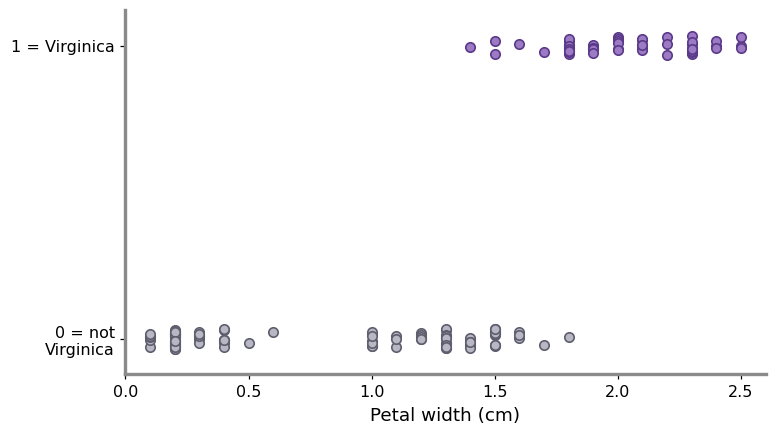

In [7]:
display(fig_iris())

### Least Squares

Code the outcome 1 or 0 and run OLS (this is the <b style="color:#73000A;">linear probability model</b>):

$$\text{Virginica}_i = \beta_0 + \beta_1\,\text{Petal}_i + u_i$$

$E[\text{Virginica} \mid \text{Petal}] = \Pr(\text{Virginica} = 1 \mid \text{Petal})$,
so the fitted line is a probability and $\beta_1$ is how much each centimetre
moves it.

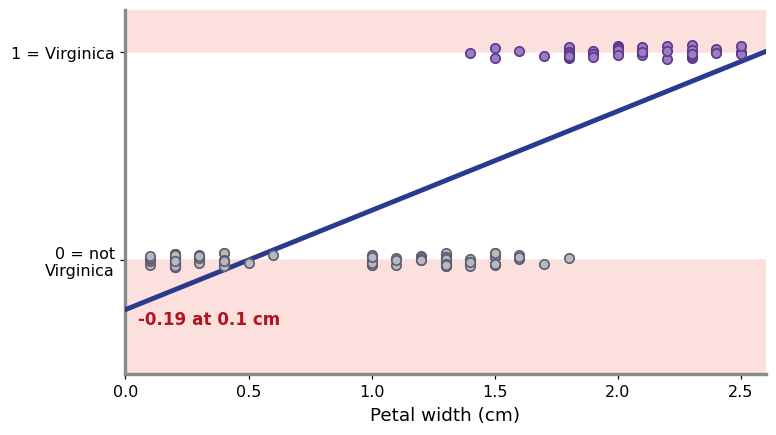

In [8]:
display(fig_iris(lpm=True))

### Linear Regression as a Network

- Multiply petal width by a weight, add a bias...
- The activation box is <b style="color:#73000A;">optional</b>: the line $y = x$ hands the Sum straight through, so leaving it out is the same thing.

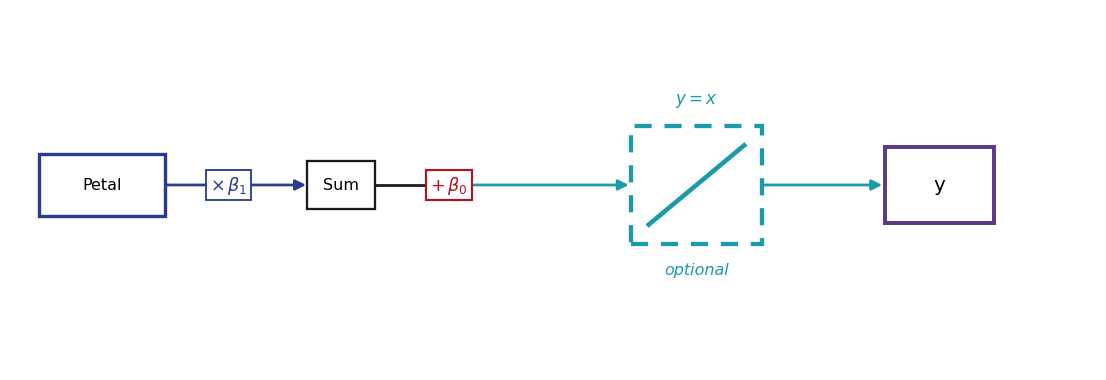

In [9]:
display(fig_neuron(act="identity", out="y"))

### Three Ways to Fit the Same Line

```python
smf.ols("virginica ~ petal", data=iris).fit()
```

Then the same line as a one node network with the $y = x$ activation, and
again with no activation at all, both trained on the sum of squared residuals.

In [10]:
import torch
import torch.nn as nn

# ---------------------------------------------------------------- 1. OLS
# The usual regression: virginica (0 or 1) on petal width.
ols = smf.ols("virginica ~ petal", data=IRIS).fit()
#display(ols.summary().tables[1])

# The same data as tensors, for the two networks below. Both networks are
# trained on the sum of squared residuals, the quantity OLS minimizes.
x_t = torch.tensor(PW.reshape(-1, 1))
y_t = torch.tensor(IS_VIRG).reshape(-1, 1)
sse = nn.MSELoss(reduction="sum")


def train(model, node, steps=20_000, lr=0.1 / len(PW)):
    """Plain gradient descent from zero on the sum of squared residuals.
       Returns the node's bias, its weight, and the final SSR."""
    with torch.no_grad():
        node.weight.zero_()
        node.bias.zero_()
    opt = torch.optim.SGD(model.parameters(), lr=lr)
    for _ in range(steps):
        opt.zero_grad()
        sse(model(x_t), y_t).backward()
        opt.step()
    return node.bias.item(), node.weight.item(), sse(model(x_t), y_t).item()


# ------------------------------------- 2. one node, activation y = x
# nn.Linear(1, 1) is the weight and the bias. nn.Identity() is the y = x box.
node_id = nn.Linear(1, 1).double()
net_id = nn.Sequential(node_id, nn.Identity())
fit_id = train(net_id, node_id)

# ------------------------------------- 3. one node, no activation at all
# The same nn.Linear(1, 1) with nothing after it.
node_none = nn.Linear(1, 1).double()
fit_none = train(node_none, node_none)

# ---------------------------------------------------------------- compare
rows = [("bias / constant", "%+.5f" % ols.params["Intercept"],
         "%+.5f" % fit_id[0], "%+.5f" % fit_none[0]),
        ("weight / Petal", "%+.5f" % ols.params["petal"],
         "%+.5f" % fit_id[1], "%+.5f" % fit_none[1]),
        ("sum of squared residuals", "%.4f" % ols.ssr,
         "%.4f" % fit_id[2], "%.4f" % fit_none[2])]
display(HTML(table(["", "OLS", "one node, y = x", "one node, no activation"],
                   rows, label_col=True)))

,OLS,"one node, y = x","one node, no activation"
bias / constant,-0.23930,-0.23930,-0.23930
weight / Petal,+0.47746,+0.47746,+0.47746
sum of squared residuals,13.5985,13.5985,13.5985


### What Goes Wrong With the Line

- <b style="color:#73000A;">Predictions leave 0 to 1.</b> A petal 0.1 cm wide is a Virginica with probability -0.19
- <b style="color:#73000A;">The effect is constant.</b> Each centimetre adds 0.48 whether the petal is 0.2 cm or 2 cm wide
- <b style="color:#73000A;">The errors are strange.</b> The error can only be $-\hat p$ or $1 - \hat p$, so it is not normal,
  and its variance is $p(1-p)$, which changes with petal width

## Maybe a Sigmoid Would Be Better?

Instead of a line, logistic regression fits an s-shaped <b style="color:#73000A;">squiggle</b> that gives the
predicted probability, always between 0 and 1.

- Close to the top: a high probability of a Virginica
- Close to the bottom: a low one

Reminder:  $\sigma(x) = \dfrac{1}{1 + e^{-x}}$

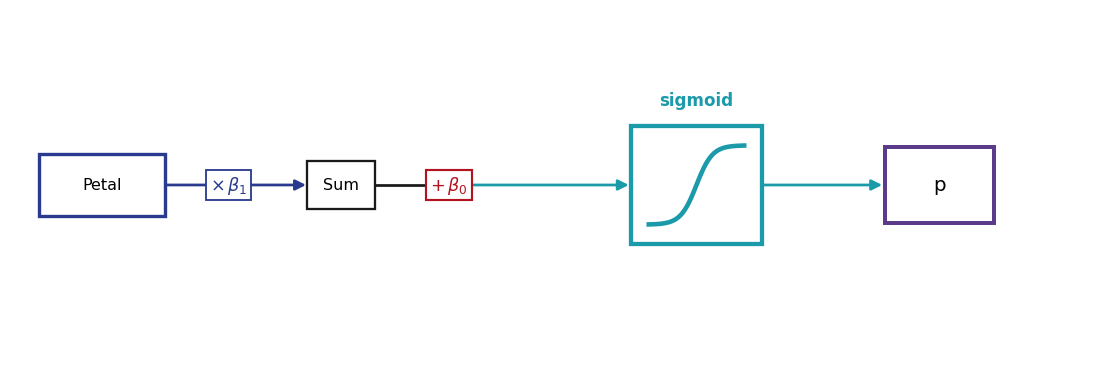

In [11]:
display(fig_neuron())

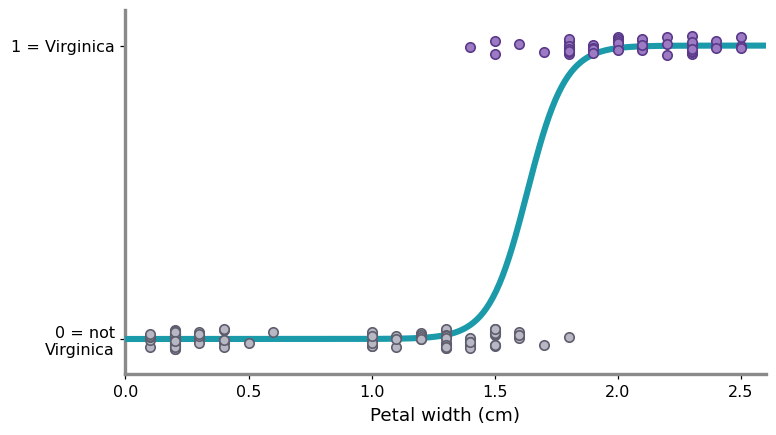

In [12]:
display(fig_iris(sq=SQ_A))

### Why Might It Make More Sense Intuitively?
#### Another Example

- y is home ownership
- x is income
- Not much of a change in probability of y=1 at low OR high levels with most in the midddle
   - Note, approx linear in the middle...

### A Latent-Index View

Suppose there is an unobserved index,

$$ y_i^* = \beta_0 + \beta_1 x_i + \varepsilon_i, $$


- We don’t get to observe $y_i^*$ itself
- we only observe the binary outcome $y_i$ which indicates whether $y_i^*$ crosses a certain threshold. 
- Without loss of generality, we can take that threshold to be 0 : $$ y_i = \begin{cases} 1 & \text{if } y_i^* > 0,\\ 0 & \text{if } y_i^* \le 0~. \end{cases} $$






### A Latent-Index View CONT...




So for a given $x_i$, the probability of seeing $y_i=1$ is the probability that the latent index ends up above the threshold: $$ P(y_i = 1 \mid x_i) \;=\; P(y_i^* > 0 \mid x_i). $$ 

Substituting the definition of $y_i^*$, this is: $$ P(y_i = 1 \mid x_i) \;=\; P(\beta_0 + \beta_1 x_i + \varepsilon_i > 0). $$ 

We can rearrange the inequality inside the probability: $$ P(y_i = 1 \mid x_i) \;=\; P\!\Big(\varepsilon_i > -(\beta_0 + \beta_1 x_i)\Big). $$ 


### A Latent-Index View CONT...

Call the index $z_i = \beta_0 + \beta_1 x_i$. Then

$$ P(y_i = 1 \mid x_i) = P(\varepsilon_i > -z_i). $$

Let $F$ be the CDF of the error term $\varepsilon_i$, so $F(a) = P(\varepsilon_i \le a)$ for any number $a$.

The probability that $\varepsilon_i$ *exceeds* $a$ is $1 - F(a)$. Here $a = -z_i$, so

$$ P(y_i = 1 \mid x_i) = 1 - F(-z_i). $$

If $\varepsilon_i$ is symmetric around 0, then $1 - F(-z_i) = F(z_i)$, and

$$ P(y_i = 1 \mid x_i) = F(\beta_0 + \beta_1 x_i). $$


## Key Step
### What is the distribution of the error?

- **Logistic distribution:** If $\varepsilon_i$ follows a logistic distribution, then $F(t) = \frac{1}{1+e^{-t}}$ (the logistic CDF). In this case, our model is a **logistic regression**, and $P(y_i=1 \mid x_i)$ will be a logistic sigmoid function. 

- **Standard normal distribution:** If $\varepsilon_i$ is standard normal, then $F(t) = \Phi(t)$ (the normal CDF). In this case, we have a **probit regression**, and $P(y_i=1 \mid x_i)$ will follow the familiar S-shaped curve of the normal CDF. Both the logistic and the normal distributions are symmetric around zero, which means they satisfy $F(-z) = 1 - F(z)$. 

Thanks to this symmetry, we can simplify our probability expression: $$ P(y_i = 1 \mid x_i) = 1 - F\!\big(-(\beta_0 + \beta_1 x_i)\big) = F(\beta_0 + \beta_1 x_i). $$

In other words, the probability of $y=1$ is just the CDF evaluated at the linear index $\beta_0 + \beta_1 x_i$. 


### The Logistic Function

With a logistic $\varepsilon$, $F$ is

$$P = \frac{1}{1 + e^{-z}} = \frac{e^{z}}{1 + e^{z}}$$

The two forms are the same: multiply the top and bottom of the first by $e^{z}$.

## Odds and Log Odds

The odds are the probability of a Virginica over the probability of not:

$$\frac{P}{1-P} = \frac{e^{z}/(1+e^{z})}{1/(1+e^{z})} = e^{z}$$

Take logs, and the <b style="color:#73000A;">log odds</b> are a straight line in petal width:

$$\log\frac{P}{1-P} = z = \beta_0 + \beta_1\,\text{Income}$$

### Why is this log-odds form useful?

Because it means each coefficient $\beta_j$ has a consistent interpretation: it’s the increase in the log-odds associated with a one-unit increase in $x_j$, holding other variables constant. Exponentiating that, $e^{\beta_j}$ is the **multiplicative change in the odds** for a one-unit increase in $x_j$. 

- If $\beta_1 = 0.5$, then $e^{0.5} \approx 1.65$. The odds of $y=1$ are multiplied by 1.65 for each 1-unit increase in $x_1$. 
- If $\beta_1 = 0$, then $e^{0} = 1$. The odds stay the same when $x_1$ changes, meaning $x_1$ has no effect. 
- If $\beta_1 = -0.4$, then $e^{-0.4} \approx 0.67$. Each 1-unit increase in $x_1$ multiplies the odds by about 0.67 (a one-third reduction in the odds). 


#  Homeownership Example
$y_i=1$ if family $i$ owns a home, and $x_i$ is their income (in appropriate units)... 

Suppose the estimated coefficient on income is $\beta_1 = 0.7$. 
Then for each additional unit of income, the odds of owning a home increase by a factor of $e^{0.7} \approx 2.0$...roughly a doubling of the odds. 

If another variable (say $\beta_2$ for education level) is $-0.4$, then each extra unit of that variable (e.g. each additional family member without a college degree, if that’s how the variable is defined) would *decrease* the odds of homeownership to 67% of what they were, all else equal. 

## Back to the Irises

We find a new iris with petals 1.7 cm wide. Read the squiggle above that
width.

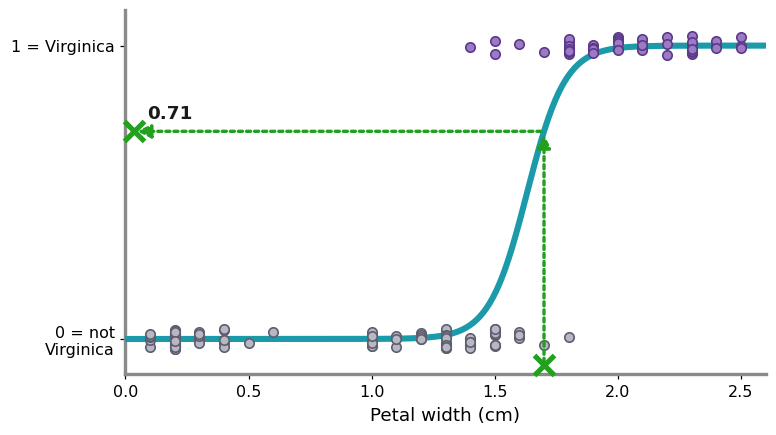

In [13]:
display(fig_iris(sq=SQ_A, new=1.7))

### From a Probability to a Class

To classify, pick a threshold. Usually it is 0.5: above it we say Virginica,
at or below it we say not. 0.71 is above 0.5, so this flower is called a
Virginica.

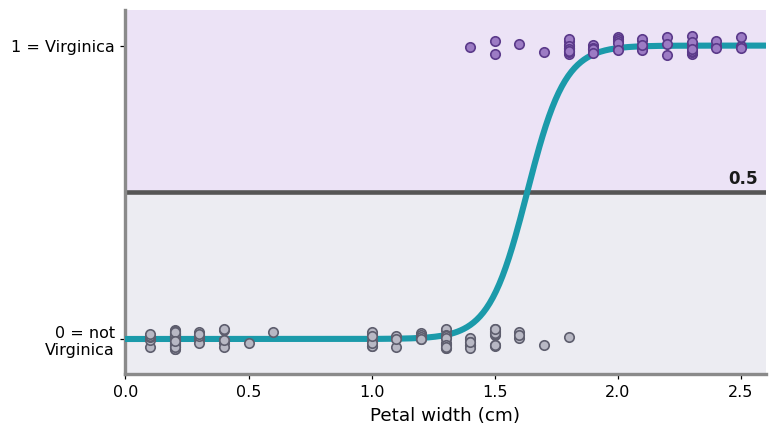

In [14]:
display(fig_iris(sq=SQ_A, threshold=True))

# FITTING THE SQUIGGLE

- Linear regression fits a line by minimizing the sum of squared residuals
- Logistic regression swaps the residuals for <b style="color:#73000A;">likelihoods</b>, which are y-axis
  coordinates on the squiggle
- Then it picks the squiggle with the <b style="color:#73000A;">maximum likelihood</b>

To see it by hand, take nine flowers from where the species overlap.

Write $Y = 1$ for a Virginica and $p$ for the squiggle's value ($p_i = F(\beta_0 + \beta_1 x_{i1} + \cdots + \beta_k x_{ik})$. 

Then...

$$\text{Likelihood} = p_i^{\,Y}\,(1-p)^{\,1-Y}$$

Put $Y = 1$ in and the second factor is $(1-p)^0 = 1$, leaving $p$. Put
$Y = 0$ in and the first factor is $p^0 = 1$, leaving $1 - p$.

### The Likelihood for a Virginica

This flower is 1.8 cm wide and is a Virginica. Its likelihood is the y-axis
coordinate of the squiggle at 1.8 cm, <b style="color:#73000A;">0.9</b>.

That number is the likelihood, the predicted probability, that it is a Virginica

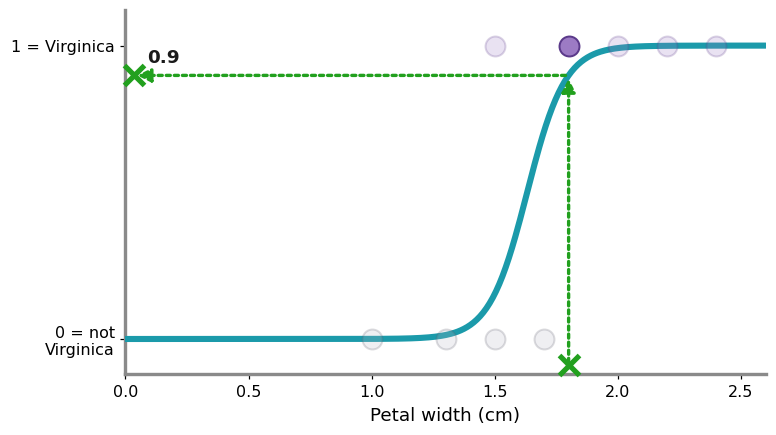

In [15]:
display(fig_iris(sq=SQ_A, nine=True, read=(5,),
                 faded=(0, 1, 2, 3, 4, 6, 7, 8)))

### A Virginica the Squiggle Gets Wrong

This one is 1.5 cm wide and is also a Virginica. The squiggle is at <b style="color:#73000A;">0.2</b>
there, so that is its likelihood.

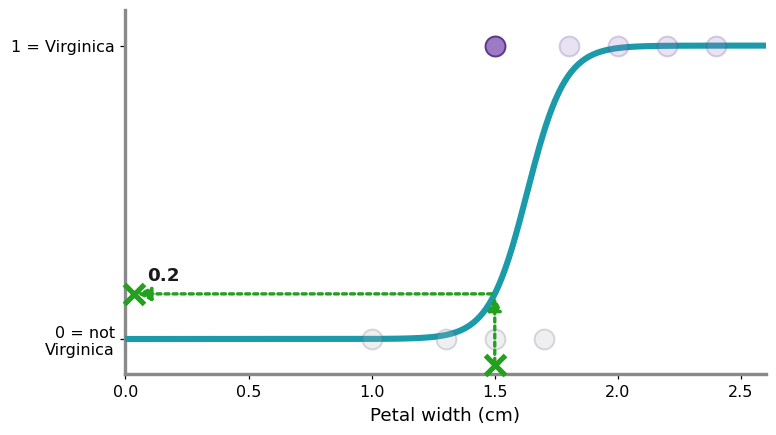

In [16]:
display(fig_iris(sq=SQ_A, nine=True, read=(4,),
                 faded=(0, 1, 2, 3, 5, 6, 7, 8)))

## A Flower That Is Not a Virginica

The y-axis is the probability that a flower <b style="color:#73000A;">is</b> a Virginica. Every flower
either is or is not, so

$$p(\text{not Virginica}) = 1 - p(\text{Virginica})$$

This Versicolor is 1.7 cm wide. The squiggle says 0.7, so its likelihood is
$1 - 0.7 = $ <b style="color:#73000A;">0.3</b>.

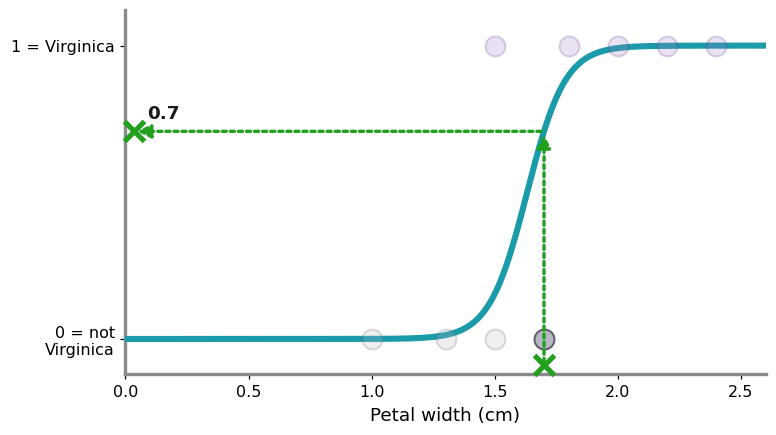

In [17]:
display(fig_iris(sq=SQ_A, nine=True, read=(3,),
                 faded=(0, 1, 2, 4, 5, 6, 7, 8)))

## Multiply Them Together

Assuming independence across observations, the **likelihood** of the whole sample (the joint probability of all observed $y_i$ given their $x_i$) is the product of each individual’s contribution: $$ L(\beta) \;=\; \prod_{i=1}^n p_i^{\,y_i}\,[\,1-p_i\,]^{\,1-y_i}~, $$

- This <b style="color:#73000A;">likelihood</b> asks: if this curve were correct, how plausible is the outcome we actually observed?

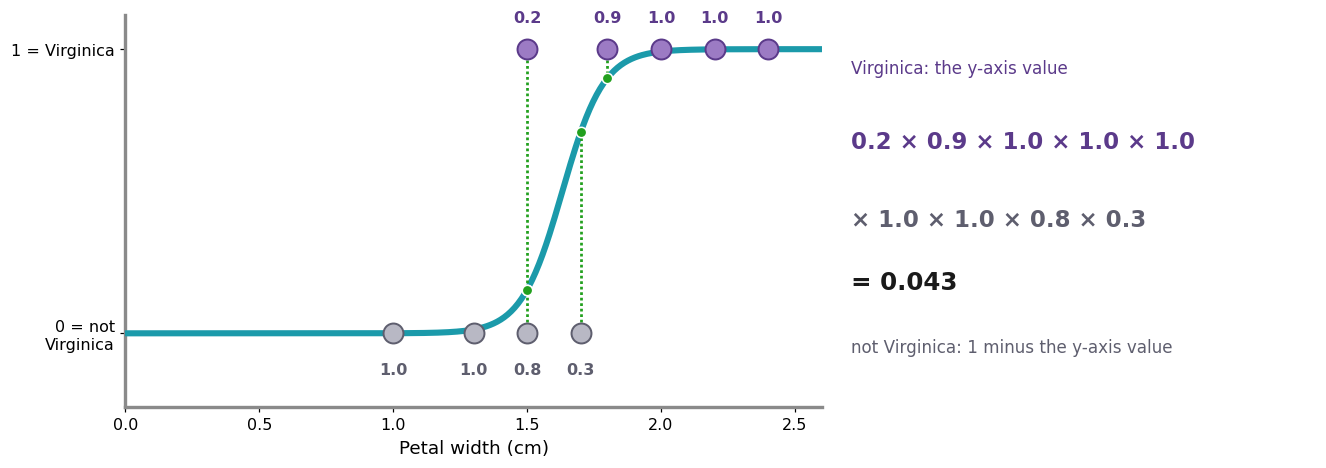

In [18]:
display(fig_likelihood_product(SQ_A))

### A Different Squiggle

Slide the squiggle 0.1 cm to the left and do it again.

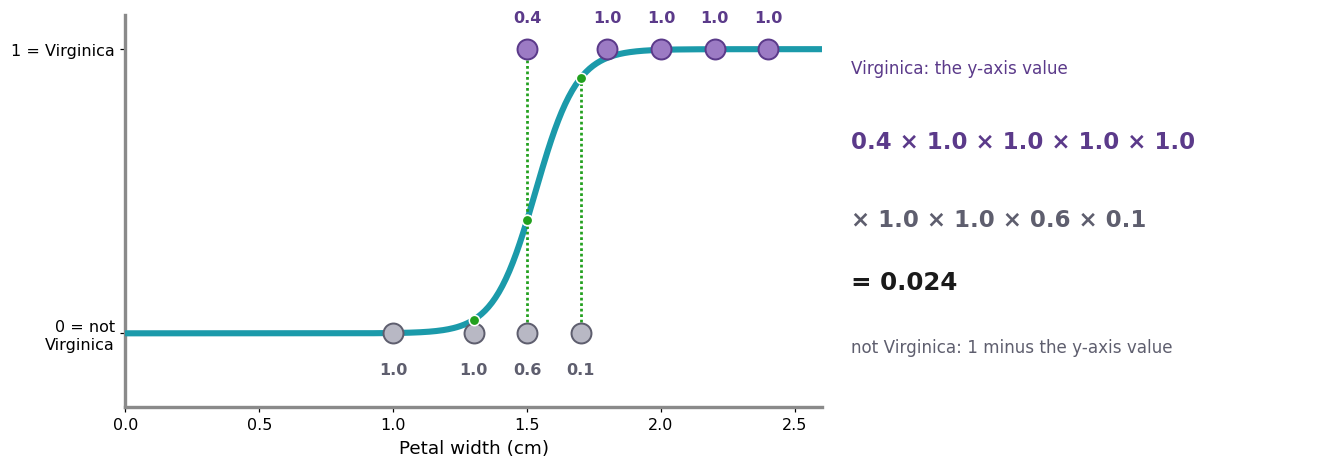

In [19]:
display(fig_likelihood_product(SQ_B))

### The Likelihood, Written Out

With $p_i$ the squiggle's value for flower $i$:

$$\mathcal{L}(\beta_0, \beta_1) = \prod_{i=1}^{n} p_i^{\,Y_i}\,(1-p_i)^{\,1-Y_i},
\qquad p_i = \frac{1}{1 + e^{-(\beta_0 + \beta_1\,\text{Petal}_i)}}$$

Change $\beta_0$ or $\beta_1$ and the squiggle moves, so the likelihood
changes.

## Take the Log

The log turns the multiplication into addition:

In [20]:
r = readings(SQ_A)
terms = []
for i, v in enumerate(r):
    who = "Virginica  " if NY[i] else "not        "
    terms.append(np.log(v))
    print("  %4.1f cm   %s likelihood %.1f   log = %6.2f" % (NX[i], who, v, np.log(v)))
print("")
print("  log(%s)" % " x ".join("%.1f" % v for v in r))
print("     = sum of the logs = %.2f" % sum(terms))

   1.0 cm   not         likelihood 1.0   log =   0.00
   1.3 cm   not         likelihood 1.0   log =   0.00
   1.5 cm   not         likelihood 0.8   log =  -0.22
   1.7 cm   not         likelihood 0.3   log =  -1.20
   1.5 cm   Virginica   likelihood 0.2   log =  -1.61
   1.8 cm   Virginica   likelihood 0.9   log =  -0.11
   2.0 cm   Virginica   likelihood 1.0   log =   0.00
   2.2 cm   Virginica   likelihood 1.0   log =   0.00
   2.4 cm   Virginica   likelihood 1.0   log =   0.00

  log(1.0 x 1.0 x 0.8 x 0.3 x 0.2 x 0.9 x 1.0 x 1.0 x 1.0)
     = sum of the logs = -3.14


### The Log Likelihood

$$\ell(\beta_0, \beta_1) = \sum_{i=1}^{n} \Big[\, Y_i \log p_i + (1-Y_i)\log(1-p_i) \Big]$$

Each flower adds the log of its own likelihood: $\log p_i$ if it is a
Virginica, $\log(1 - p_i)$ if not.

# FROM LIKELIHOOD TO CROSS ENTROPY

## Flip the Sign

- Gradient descent walks <b style="color:#73000A;">downhill</b>, and a likelihood is something we want to maximize.

- Minimizing the negative of something is the same thing as maximizing

So put a minus sign in front:

$$-\ell = \sum_{i=1}^{n} \Big[ -Y_i \log p_i - (1-Y_i)\log(1-p_i) \Big]$$

This is the <b style="color:#73000A;">cross entropy</b>.

### Flower by Flower

In [21]:
r = readings(SQ_A)
rows = []
for i in range(len(NX)):
    p = round(float(p_virg(NX[i])), 1)
    what = p if NY[i] else round(1 - p, 1)
    rows.append(("%.1f" % NX[i], "yes" if NY[i] else "no", "%.1f" % p,
                 "%.1f" % what, "-log(%.1f) = %.2f" % (what, -np.log(what) + 0.0)))
total = -np.log(r).sum()
display(HTML(table(["Petal (cm)", "Virginica?", "p(Virginica)",
                    "p(what happened)", "Cross Entropy"], rows)
             + note("Total Cross Entropy = %.2f, and the log likelihood was -%.2f"
                    % (total, total))))

Petal (cm),Virginica?,p(Virginica),p(what happened),Cross Entropy
1.0,no,0.0,1.0,-log(1.0) = 0.00
1.3,no,0.0,1.0,-log(1.0) = 0.00
1.5,no,0.2,0.8,-log(0.8) = 0.22
1.7,no,0.7,0.3,-log(0.3) = 1.20
1.5,yes,0.2,0.2,-log(0.2) = 1.61
1.8,yes,0.9,0.9,-log(0.9) = 0.11
2.0,yes,1.0,1.0,-log(1.0) = 0.00
2.2,yes,1.0,1.0,-log(1.0) = 0.00
2.4,yes,1.0,1.0,-log(1.0) = 0.00


### Back to our Graphic...

The flower 1.8 cm wide, with the squiggle's $\beta_1 = 12.95$ and
$\beta_0 = -21.13$:

$$1.8 \times 12.95 = 23.31, \qquad 23.31 + (-21.13) = 2.18, \qquad
\frac{1}{1 + e^{-2.18}} = 0.90$$

The same 0.9 we read off the squiggle.

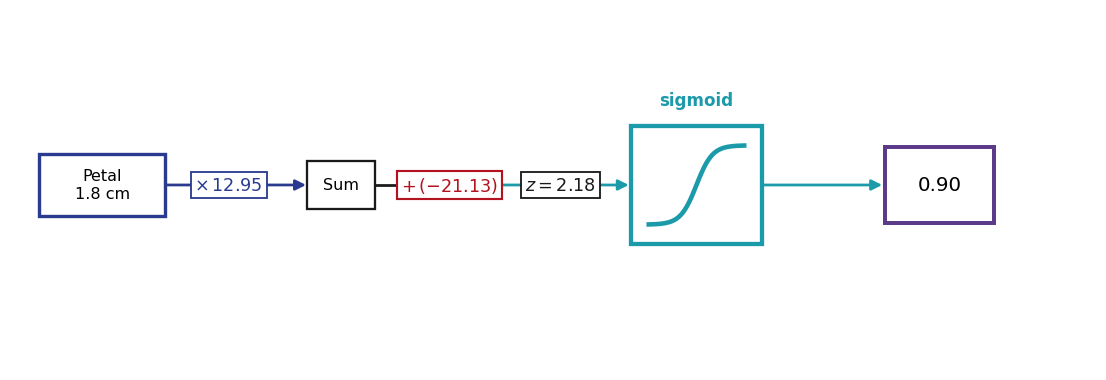

In [22]:
display(fig_neuron(inputs=(("Petal", r"$\times\,12.95$"),),
                   bias=r"$+\,(-21.13)$", values=["1.8 cm"],
                   z=1.8 * 12.95 - 21.13,
                   p=float(p_virg(1.8))))

## Needed for Gradient Descent...

$P = \dfrac{e^{z}}{1+e^{z}}$, so by the quotient rule

$$\frac{dP}{dz} = \frac{e^{z}\left(1+e^{z}\right) - e^{z} \cdot e^{z}}{\left(1+e^{z}\right)^{2}}
= \frac{e^{z}}{\left(1+e^{z}\right)^{2}}
= \frac{e^{z}}{1+e^{z}} \cdot \frac{1}{1+e^{z}} = P\,(1-P)$$

### The Chain Rule for One Flower

With $z_i = \beta_0 + \beta_1 x_i$, one flower's cross entropy against $\beta_1$:

$$\frac{\partial}{\partial \beta_1}\Big[-Y_i \log P_i - (1-Y_i)\log(1-P_i)\Big]
= \underbrace{\left[-\frac{Y_i}{P_i} + \frac{1-Y_i}{1-P_i}\right]}_{\text{the logs}}
\cdot \underbrace{P_i(1-P_i)}_{\text{the sigmoid}}
\cdot \underbrace{x_i}_{\partial z_i/\partial \beta_1}$$

Three links, one per layer: the log, the squash, the weighted sum.

### The Squashing Cancels

Multiply the first two links out:

$$\left[-\frac{Y_i}{P_i} + \frac{1-Y_i}{1-P_i}\right] P_i(1-P_i)
= -Y_i(1-P_i) + (1-Y_i)P_i = P_i - Y_i$$

So the gradient of the total cross entropy is

$$\frac{\partial\,\text{CE}}{\partial \beta_1} = \sum_i (P_i - Y_i)\,x_i,
\qquad \frac{\partial\,\text{CE}}{\partial \beta_0} = \sum_i (P_i - Y_i)$$

# SIDE BY SIDE ON ALL 150 FLOWERS

## The Economist's Way: `smf.logit`

```python
smf.logit("virginica ~ petal", data=iris).fit()
```

Newton's method on the log likelihood, standard errors from its curvature.

In [23]:
X1 = np.c_[np.ones(len(PW)), PW]
Y = IS_VIRG
fit1 = smf.logit("virginica ~ petal", data=IRIS).fit(disp=False)
display(fit1.summary().tables[1])
print("log likelihood  %.4f      McFadden pseudo R squared  %.3f"
      % (fit1.llf, fit1.prsquared))

,coef,std err,z,P>|z|,[0.025,0.975]
Intercept,-21.1256,4.597,-4.596,0.000,-30.135,-12.116
petal,12.9475,2.843,4.554,0.000,7.376,18.519


log likelihood  -16.7104      McFadden pseudo R squared  0.825


## The Network's Way: One Neuron, Walking Downhill

```python
net  = nn.Linear(1, 1)                            # one weight, one bias
loss = nn.BCEWithLogitsLoss(reduction="sum")      # sigmoid, then cross entropy
opt  = torch.optim.SGD(net.parameters(), lr=4 / 150)

for _ in range(50_000):
    opt.zero_grad()
    loss(net(petal), virginica).backward()        # autograd finds the gradient
    opt.step()
```

And the same walk written by hand: $\beta \leftarrow \beta - \frac{4}{n}\sum_i (P_i - Y_i)\,\mathbf{x}_i$

In [24]:
import torch
import torch.nn as nn

STEPS = 50_000
SHOW = [1, 10, 100, 1_000, 10_000, 50_000]

b = np.zeros(2)                                  # our own loop
path = {0: b.copy()}
for k in range(1, STEPS + 1):
    P = sigmoid(X1 @ b)
    b = b - 4.0 * X1.T @ (P - Y) / len(Y)
    if k in SHOW:
        path[k] = b.copy()
b_loop = b

net = nn.Linear(1, 1).double()                   # PyTorch
with torch.no_grad():
    net.weight.zero_()
    net.bias.zero_()
petal = torch.tensor(PW.reshape(-1, 1))
virginica = torch.tensor(Y).reshape(-1, 1)
lossf = nn.BCEWithLogitsLoss(reduction="sum")
opt = torch.optim.SGD(net.parameters(), lr=4.0 / len(Y))
tpath = {}
for k in range(1, STEPS + 1):
    opt.zero_grad()
    lossf(net(petal), virginica).backward()
    opt.step()
    if k in SHOW:
        tpath[k] = (net.bias.item(), net.weight.item())

rows = [("{:,}".format(k), "%+.4f" % path[k][0], "%+.4f" % tpath[k][0],
         "%+.4f" % path[k][1], "%+.4f" % tpath[k][1]) for k in SHOW]
display(HTML(table(["step", "bias, our loop", "bias, PyTorch",
                    "weight, our loop", "weight, PyTorch"], rows, shade=5)))

step,"bias, our loop","bias, PyTorch","weight, our loop","weight, PyTorch"
1,-0.6667,-0.6667,+0.3027,+0.3027
10,-2.9164,-2.9164,+2.8214,+2.8214
100,-9.0196,-9.0196,+5.5186,+5.5186
"1,000",-18.0152,-18.0152,+11.0303,+11.0303
"10,000",-21.1250,-21.1250,+12.9471,+12.9471
"50,000",-21.1256,-21.1256,+12.9475,+12.9475


### This Is Logit

- The one neuron network <b style="color:#73000A;">is</b> logistic regression
- Economists have fit it for a century; machine learning calls it a neuron
- Minimizing cross entropy is maximizing the likelihood, so the two land on
  the same numbers

# MORE THAN ONE INPUT

## Add Sepal Width

Nothing about the node changes. Each input gets its own arrow and its own
weight, they land in the same Sum, and there is still one bias and one
sigmoid.

$$z = \beta_0 + \beta_1\,\text{Petal} + \beta_2\,\text{Sepal}$$

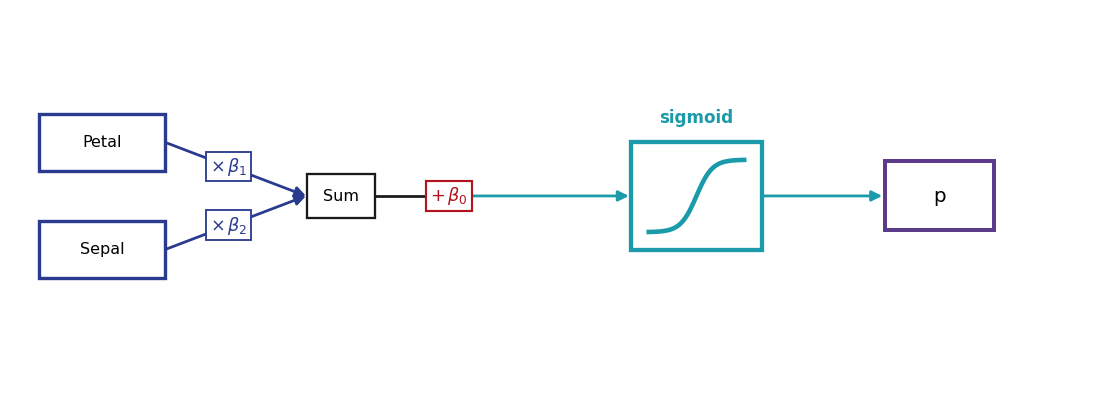

In [25]:
display(fig_neuron(inputs=(("Petal", r"$\times\,\beta_1$"),
                           ("Sepal", r"$\times\,\beta_2$"))))

### Two Inputs Need a Third Dimension

Petal width along one axis, sepal width along the other, and the probability
up the side. The squiggle becomes a <b style="color:#73000A;">sheet bent by the sigmoid</b>.

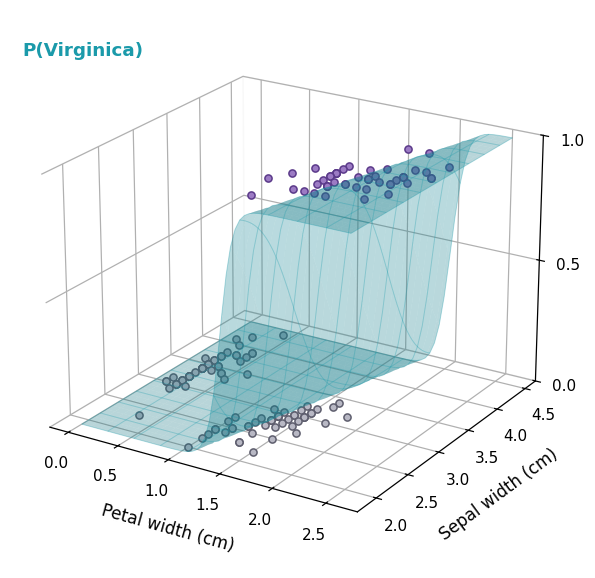

In [26]:
fit3 = smf.logit("virginica ~ petal + sepal", data=IRIS).fit(disp=False)
display(fig_logit_surface(fit3.params.values))

# MORE THAN ONE OUTPUT

## Two Measurements In, Three Species Out

Instead of choosing the bend ourselves, let hidden nodes find it. This network
takes the width of a <b style="color:#73000A;">petal</b> and the width of a <b style="color:#73000A;">sepal</b> and gives one output for each
species: Setosa, Versicolor and Virginica.

- Weights times inputs, plus a bias: the same $\beta_0 + \beta_1\,\text{Petal} + \beta_2\,\text{Sepal}$
- Then a bend. Here the bend is a <b style="color:#73000A;">ReLU</b>, not a sigmoid to match the references
- And this time each bent output gets <b style="color:#73000A;">its own weight</b> before it is added up

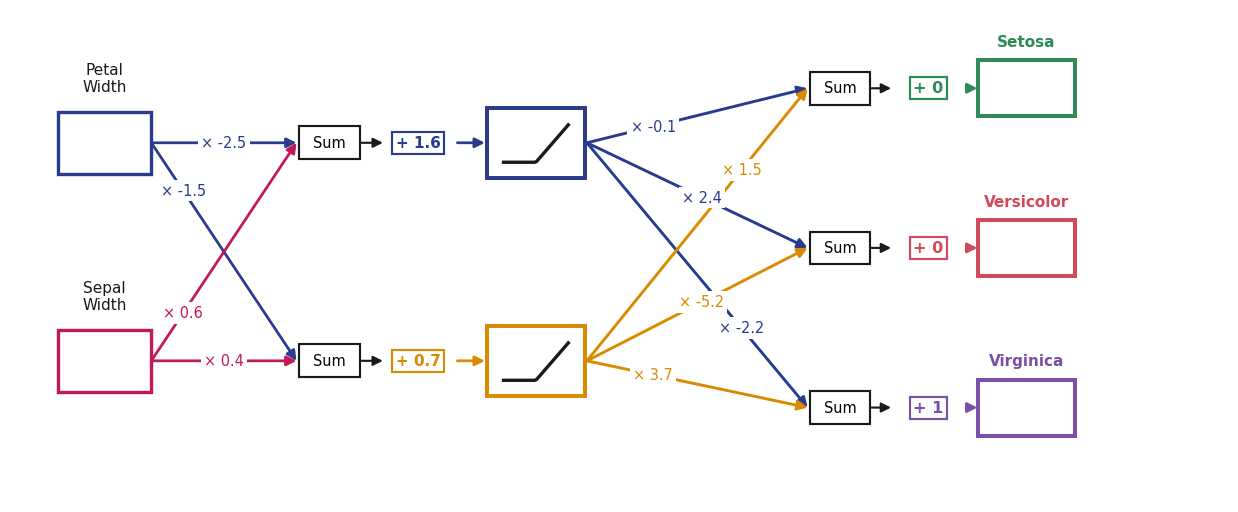

In [27]:
display(fig_network())

### Start With One Output

Keep both inputs but only the output for Setosa. The other two come back once
this one makes sense.

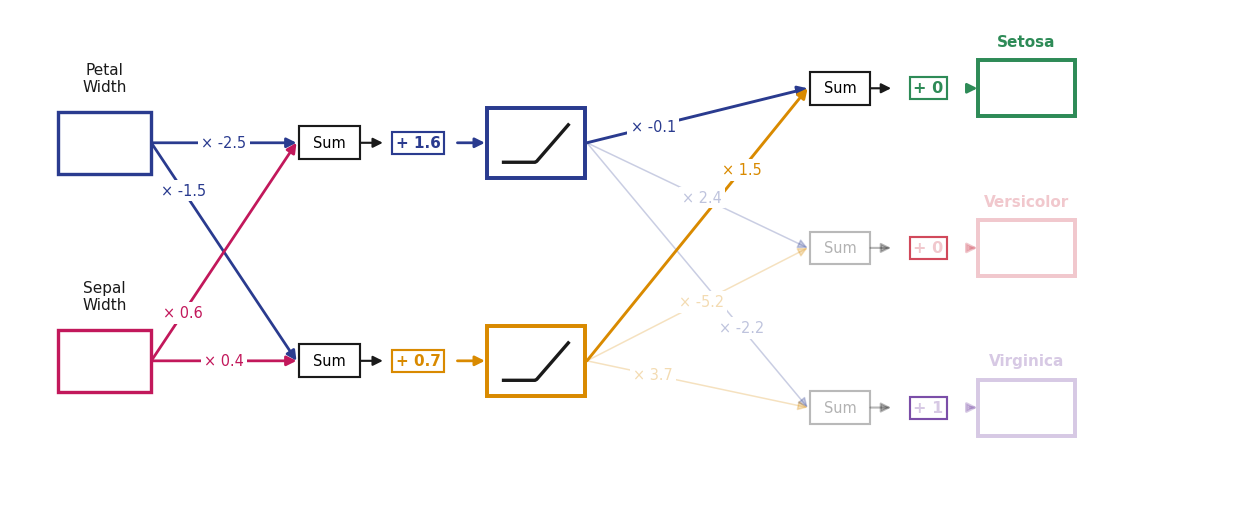

In [28]:
display(fig_network(active=(0,)))

## Two Inputs and One Output Need a Third Dimension

Petal width gets one axis, sepal width gets another, and the output for
Setosa goes up the side.

Both inputs are scaled to run from <b style="color:#73000A;">0</b>, the smallest width in the training
data, to <b style="color:#73000A;">1</b>, the largest.

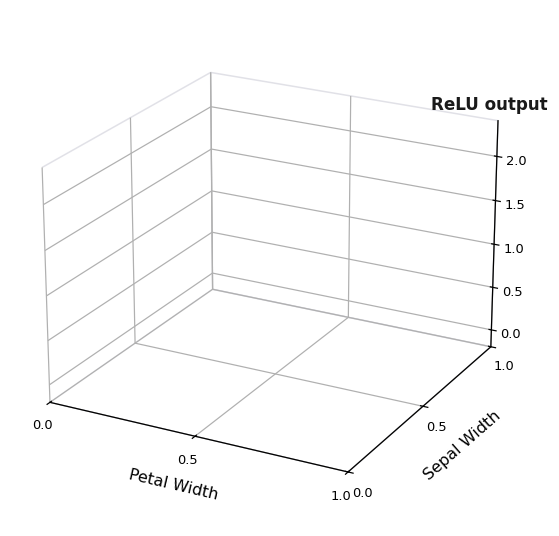

In [29]:
display(fig_surface(("top",), dots="none", surface=False,
                    zlim=(-0.2, 2.4)))

## Petal 0, Sepal 0

Start in the corner where both widths are 0, and work out the top node:

$$(0 \times -2.5) + (0 \times 0.6) + 1.6 = 1.6$$

1.6 is the x-axis coordinate for the ReLU. It is above 0, so the ReLU passes it
through and the y-axis coordinate is also <b style="color:#73000A;">1.6</b>.

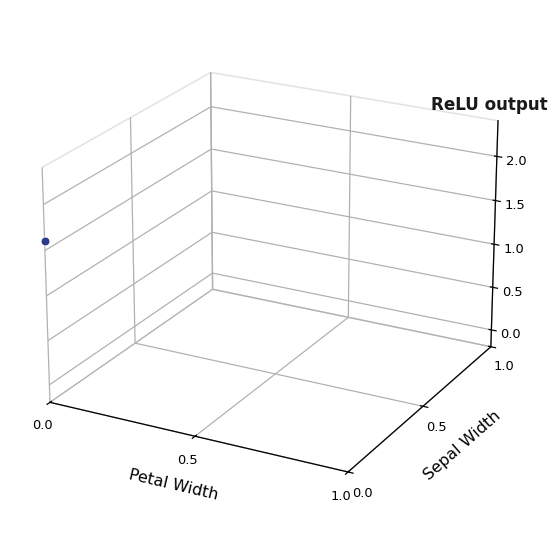

In [30]:
display(fig_surface(("top",), dots=1, surface=False,
                    zlim=(-0.2, 2.4)))

### Petal 0.2, Sepal 0

$$(0.2 \times -2.5) + (0 \times 0.6) + 1.6 = 1.1$$

Above 0 again, so the ReLU gives <b style="color:#73000A;">1.1</b>, and that is the next dot.

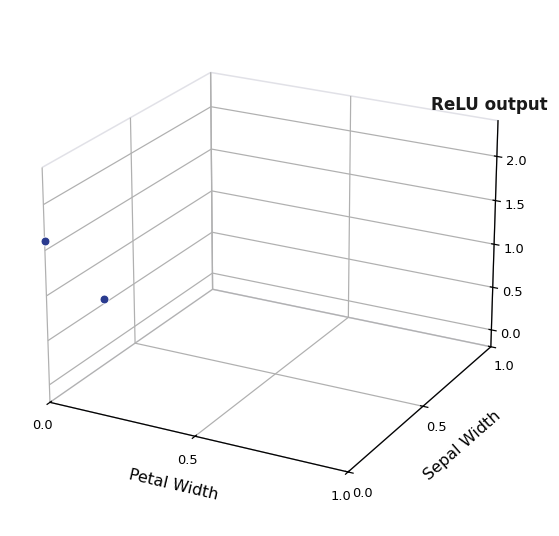

In [31]:
display(fig_surface(("top",), dots=2, surface=False,
                    zlim=(-0.2, 2.4)))

### The Rest of the First Row

Keep sepal width at 0 and run petal width all the way to 1.

sepal width 0, top node
  petal 0.0:  (0.0 x -2.5) + (0 x 0.6) + 1.6 =  1.60   ReLU -> 1.60
  petal 0.2:  (0.2 x -2.5) + (0 x 0.6) + 1.6 =  1.10   ReLU -> 1.10
  petal 0.4:  (0.4 x -2.5) + (0 x 0.6) + 1.6 =  0.60   ReLU -> 0.60
  petal 0.6:  (0.6 x -2.5) + (0 x 0.6) + 1.6 =  0.10   ReLU -> 0.10
  petal 0.8:  (0.8 x -2.5) + (0 x 0.6) + 1.6 = -0.40   ReLU -> 0.00
  petal 1.0:  (1.0 x -2.5) + (0 x 0.6) + 1.6 = -0.90   ReLU -> 0.00


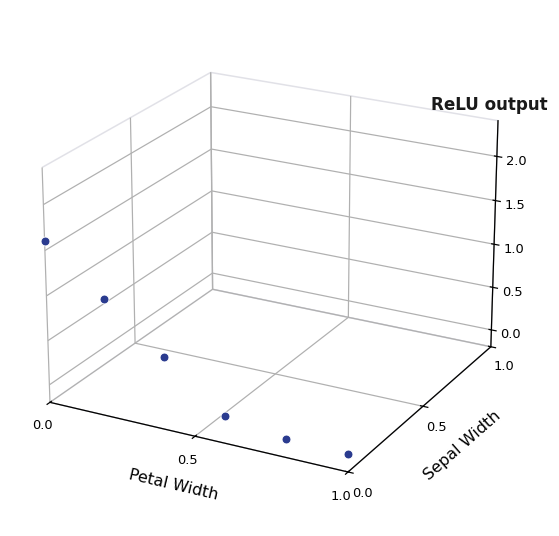

In [32]:
print("sepal width 0, top node")
for petal in (0.0, 0.2, 0.4, 0.6, 0.8, 1.0):
    x = petal * W_IN[0, 0] + 0.0 * W_IN[1, 0] + B_HID[0]
    print("  petal %.1f:  (%.1f x -2.5) + (0 x 0.6) + 1.6 = %5.2f   ReLU -> %.2f"
          % (petal, petal, x, max(x, 0)))
display(fig_surface(("top",), dots=6, surface=False, zlim=(-0.2, 2.4)))

### Every Row: the Blue Bent Surface

Do the same for sepal width 0.2, 0.4, and on up to 1. The dots make a
<b style="color:#73000A;">blue bent surface</b>. The bend is where the ReLU sets the output to 0.

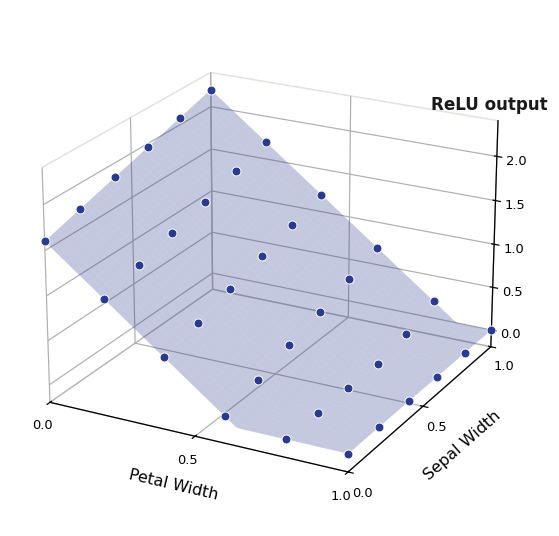

In [33]:
display(fig_surface(("top",), zlim=(-0.2, 2.4)))

## Multiply by the Weight to Setosa, -0.1

Every y-axis coordinate on the blue bent surface gets multiplied by $-0.1$. At
petal 0 and sepal 0:

$$1.6 \times -0.1 = -0.16$$

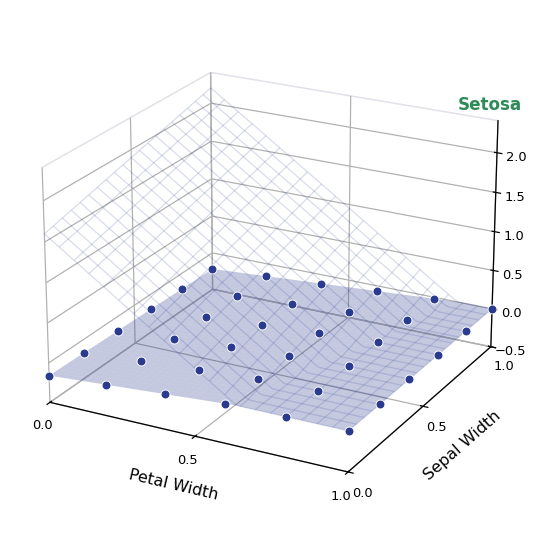

In [34]:
display(fig_surface(("topw",), zlim=(-0.5, 2.4), ghost="top"))

## The Bottom Node: the Orange Bent Surface

The same steps through the bottom node. At petal 0 and sepal 0:

$$(0 \times -1.5) + (0 \times 0.4) + 0.7 = 0.7$$

The ReLU passes 0.7 through, and the weight to Setosa is $1.5$:

$$0.7 \times 1.5 = 1.05$$

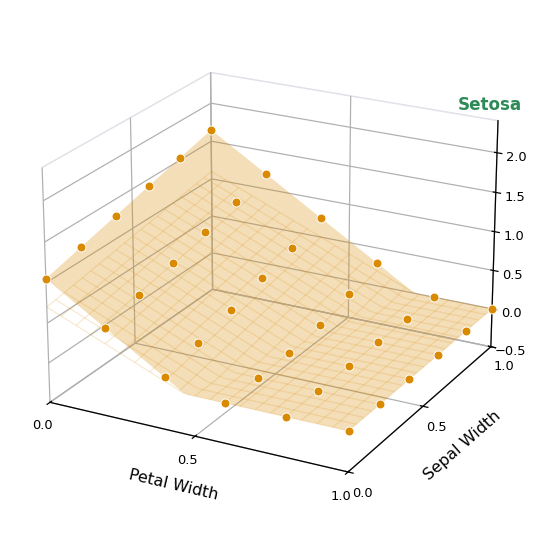

In [35]:
display(fig_surface(("botw",), zlim=(-0.5, 2.4), ghost="bot"))

## Add the Two Surfaces

Add the y-axis coordinates of the blue and orange bent surfaces, point by
point. At petal 0 and sepal 0:

$$-0.16 + 1.05 = 0.89$$

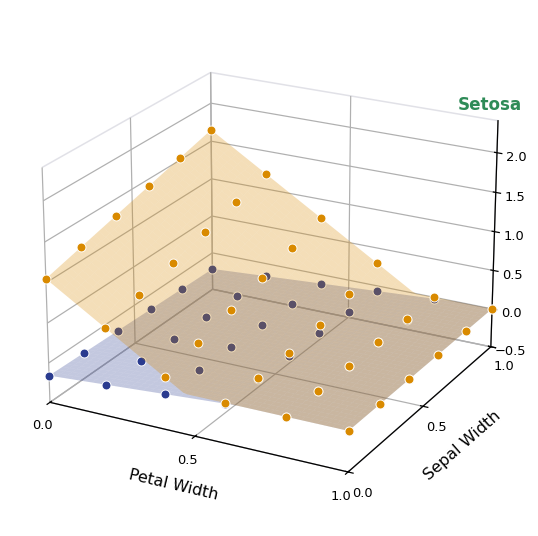

In [36]:
display(fig_surface(("topw", "botw"), zlim=(-0.5, 2.4)))

### The Green Crinkled Surface

Doing that at every point gives a <b style="color:#73000A;">green crinkled surface</b>.

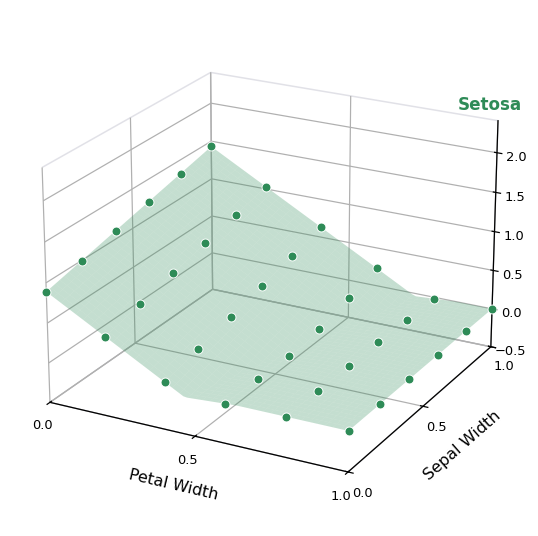

In [37]:
display(fig_surface(("sum",), zlim=(-0.5, 2.4)))

### Add the Final Bias, 0

The last step adds the Setosa bias, which is 0, so the surface does not move.
This is the output for Setosa.

- Highest when petal width is close to 0
- Lowest when petal width is close to 1

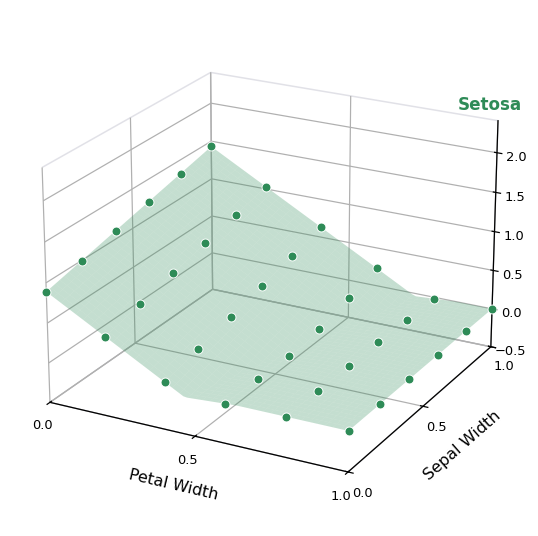

In [38]:
display(fig_surface(("out",), zlim=(-0.5, 2.4)))

## A New Iris: Petal 0.5, Sepal 0.37

We find an iris with scaled petal width 0.5 and sepal width 0.37. Read the
green crinkled surface above that point.

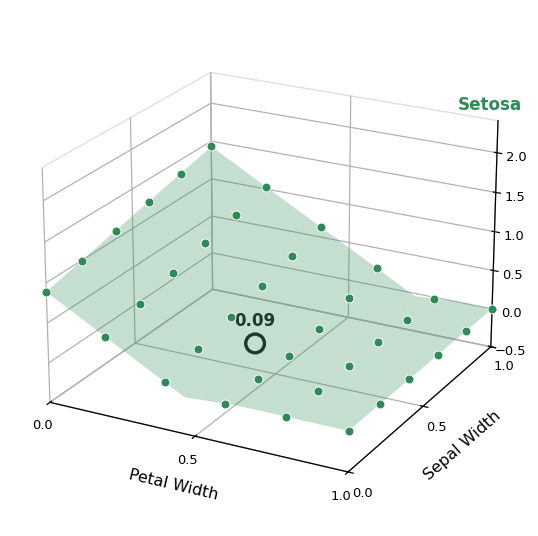

In [39]:
display(fig_surface(("out",), zlim=(-0.5, 2.4),
                    mark=(0.5, 0.37, "0.09")))

### Run the Numbers to Check

top node:     (0.50 x -2.5) + (0.37 x 0.6) + 1.6 = 0.572   ReLU -> 0.572
bottom node:  (0.50 x -1.5) + (0.37 x 0.4) + 0.7 = 0.098   ReLU -> 0.098
Setosa:       (0.572 x -0.1) + (0.098 x 1.5) + 0   = 0.09


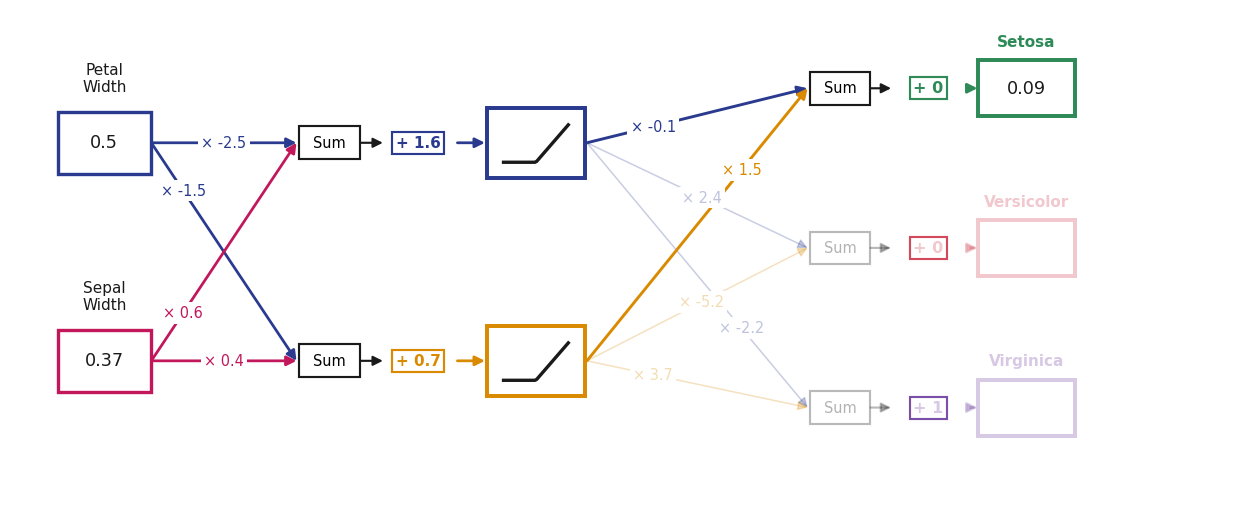

In [40]:
p, s = 0.5, 0.37
(xt, xb), (yt, yb) = hidden(p, s)
print("top node:     (%.2f x -2.5) + (%.2f x 0.6) + 1.6 = %.3f   ReLU -> %.3f"
      % (p, s, xt, yt))
print("bottom node:  (%.2f x -1.5) + (%.2f x 0.4) + 0.7 = %.3f   ReLU -> %.3f"
      % (p, s, xb, yb))
print("Setosa:       (%.3f x -0.1) + (%.3f x 1.5) + 0   = %.2f"
      % (yt, yb, yt * -0.1 + yb * 1.5))
display(fig_network(petal=p, sepal=s, raw=raw_outputs(p, s), active=(0,)))

## Versicolor: New Weights

The top and bottom nodes have not changed, so the blue and orange bent
surfaces have not either. Only the weights to the output change: <b style="color:#73000A;">× 2.4</b> for the
top node and <b style="color:#73000A;">× -5.2</b> for the bottom one.

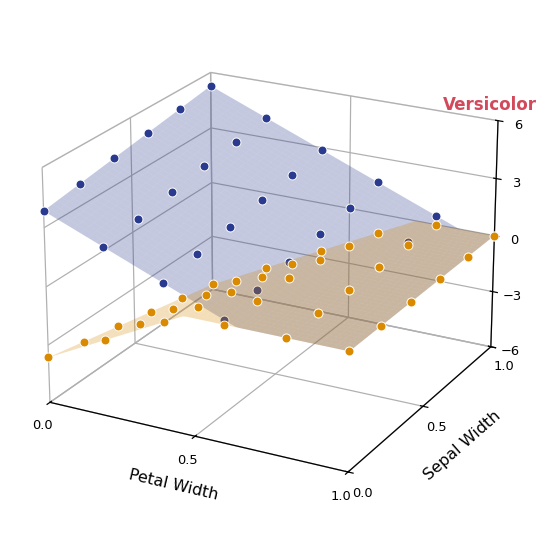

In [41]:
display(fig_surface(("topw", "botw"), k=1, zlim=(-6, 6),
                    zticks=[-6, -3, 0, 3, 6]))

### The Red Crinkled Surface

Add the two together, then add the Versicolor bias, 0.

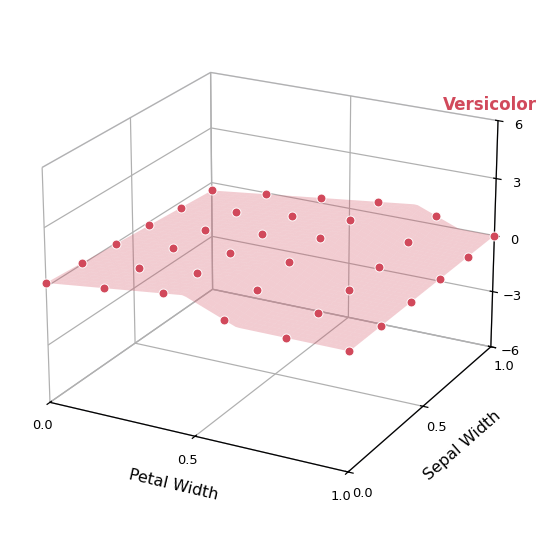

In [42]:
display(fig_surface(("out",), k=1, zlim=(-6, 6),
                    zticks=[-6, -3, 0, 3, 6]))

### Zoom In

On a y-axis from -0.5 to 1 the shape is easier to see. Versicolor scores high
when petal width is close to <b style="color:#73000A;">0.4</b>.

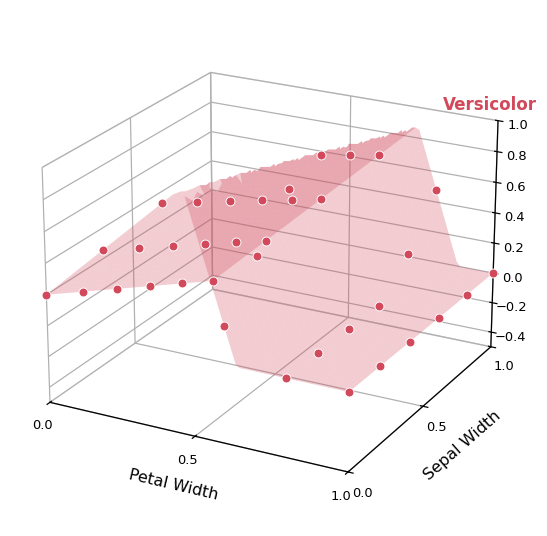

In [43]:
display(fig_surface(("out",), k=1, zlim=(-0.5, 1.0)))

## Virginica

Same blue and orange bent surfaces again, now times <b style="color:#73000A;">-2.2</b> and <b style="color:#73000A;">3.7</b>. Add them,
then add the Virginica bias, <b style="color:#73000A;">1</b>.

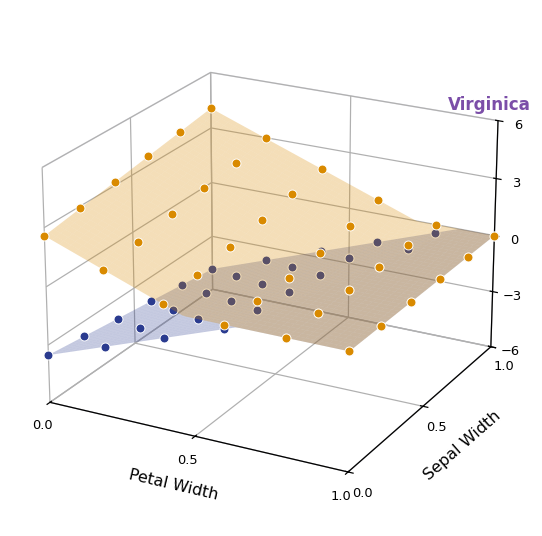

In [44]:
display(fig_surface(("topw", "botw"), k=2, zlim=(-6, 6),
                    zticks=[-6, -3, 0, 3, 6]))

### The Purple Crinkled Surface

On a y-axis from 0 to 1, Virginica scores high when petal width is close to
<b style="color:#73000A;">1</b>.

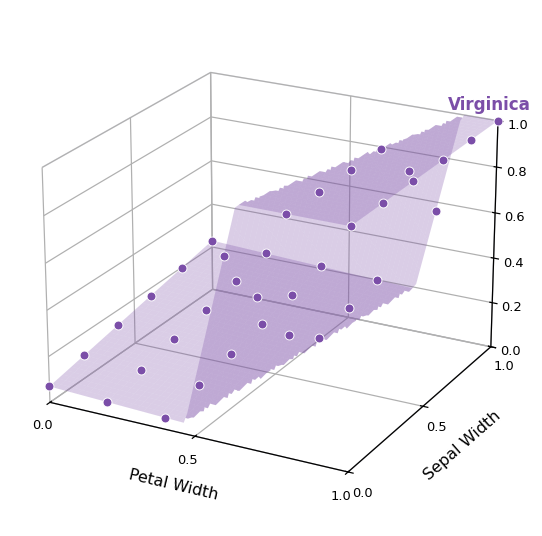

In [45]:
display(fig_surface(("out",), k=2, zlim=(0.0, 1.0)))

## Three Crinkled Surfaces

The iris we found, petal 0.5 and sepal 0.37, on all three surfaces.

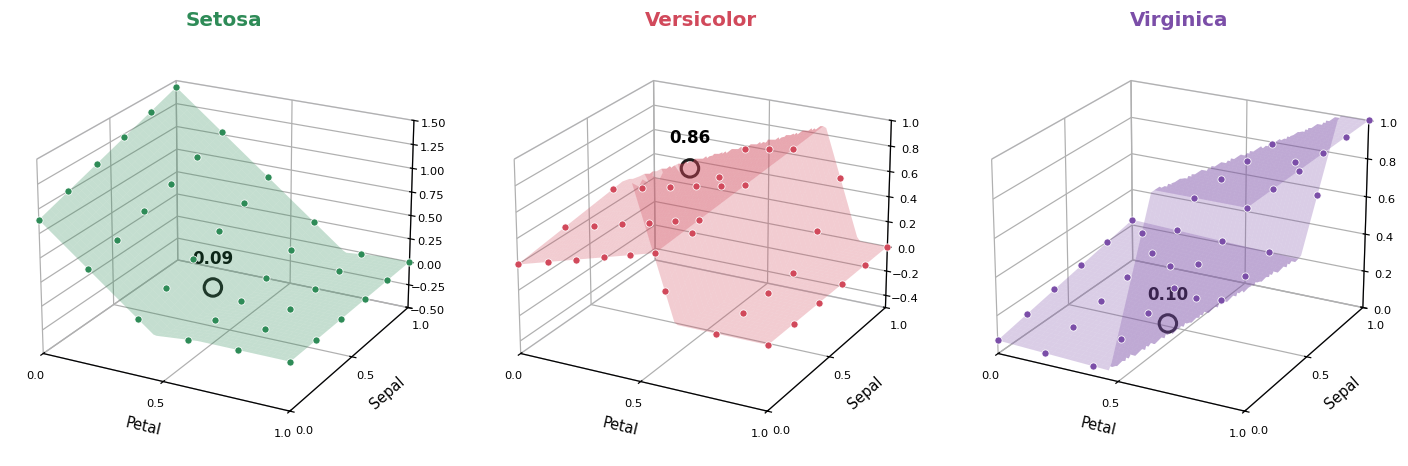

In [46]:
display(fig_three_surfaces(mark=(0.5, 0.37)))

### The Prediction

Versicolor, because its output, <b style="color:#73000A;">0.86</b>, is the closest to 1.

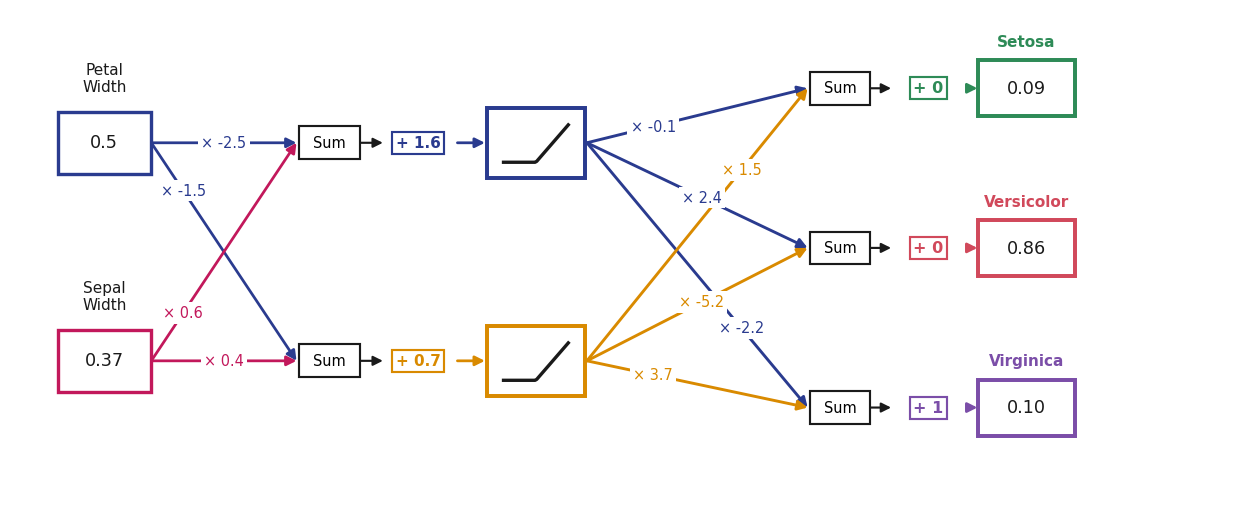

In [47]:
display(fig_network(petal=0.5, sepal=0.37,
                    raw=raw_outputs(0.5, 0.37)))

### These Are Not Probabilities Yet

- A different flower, petal 0 and sepal 1, gets raw outputs <b style="color:#73000A;">1.43</b>, -0.44 and 0.23
- One is above 1, one is below 0, and they do not add to 1
- Next lecture puts a <b style="color:#73000A;">SoftMax</b> layer on the end: it turns the three raw outputs into
  probabilities that add to 1, so the network can be trained on cross entropy

# READING THE COEFFICIENTS

## Reading It as an Economist

Back to the logit of Virginica on petal and sepal width. Three readings of
$\beta_j$:

- <b style="color:#73000A;">Log odds</b>: $\beta_j$ shifts $\log\frac{P}{1-P}$ by $\beta_j$ per unit of $X_j$
- <b style="color:#73000A;">Odds ratio</b>: $e^{\beta_j}$ multiplies the odds. It does not depend on where you sit on
  the squiggle
- <b style="color:#73000A;">Marginal effect</b>: $\partial P/\partial X_j = \beta_j\,P(1-P)$, which does

In [48]:
rows = [(n, "%+.3f" % b, "%.2f" % np.exp(0.1 * b))
        for n, b in zip(["Petal", "Sepal"], fit3.params.values[1:])]
display(HTML(table(["", "coefficient (per cm)", "odds ratio per 0.1 cm"], rows,
                   label_col=True)))

,coefficient (per cm),odds ratio per 0.1 cm
Petal,+15.700,4.81
Sepal,-3.907,0.68


### Marginal Effects

$P(1-P)$ is at most 0.25, at $P = 0.5$, so the largest effect on the
probability is a quarter of the coefficient. The <b style="color:#73000A;">average marginal effect</b> averages $\beta_j\,P_i(1-P_i)$
over every flower.

In [49]:
P3 = fit3.predict(IRIS).values
W3 = P3 * (1 - P3)
print("average of P(1 - P) over the 150 flowers:  %.4f" % W3.mean())
print("")
for n, b in zip(["Petal", "Sepal"], fit3.params.values[1:]):
    print("  %-5s  %.3f x %.4f = %.3f per cm, %.3f per 0.1 cm"
          % (n, b, W3.mean(), b * W3.mean(), 0.1 * b * W3.mean()))

average of P(1 - P) over the 150 flowers:  0.0259

  Petal  15.700 x 0.0259 = 0.407 per cm, 0.041 per 0.1 cm
  Sepal  -3.907 x 0.0259 = -0.101 per cm, -0.010 per 0.1 cm


## Logit, Probit and the LPM

Swap the logistic $\varepsilon$ for a normal one and the squiggle is the normal
CDF: that is <b style="color:#73000A;">probit</b>. The least squares line from the start is the LPM.

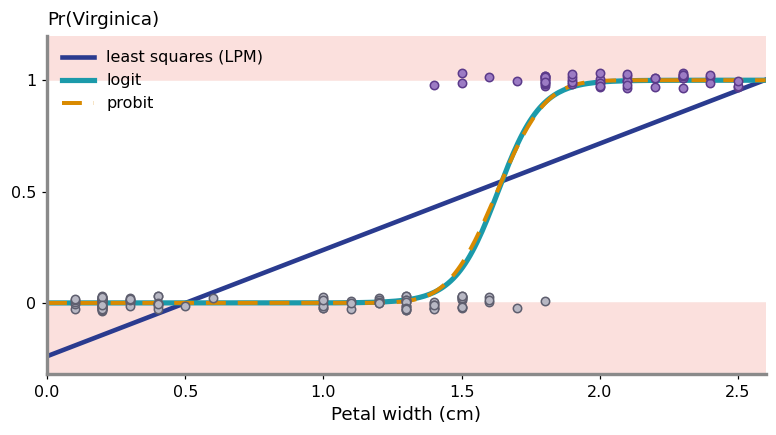

In [50]:
display(fig_cousins())

# JUDGING A CLASSIFIER

## The Confusion Matrix

Classify each flower with the petal and sepal model and a threshold of 0.5,
then count.

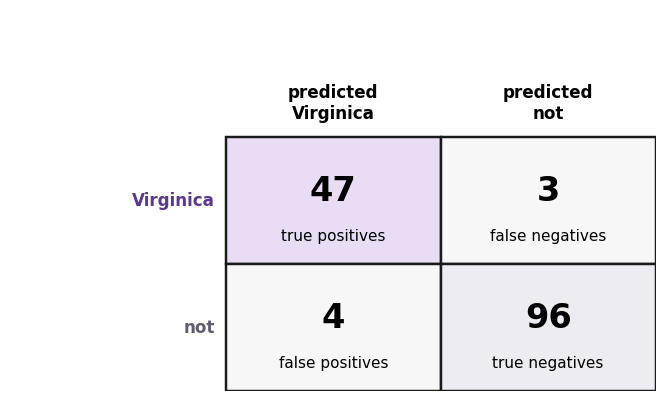

In [51]:
tp, fn, fp, tn = rates(P3, Y, 0.5)
display(fig_confusion(tp, fn, fp, tn))

### Rates

- **Accuracy**: $(TP + TN)/(TP + TN + FP + FN)$, the share of all flowers
  classified correctly
- **Sensitivity**, or **recall**: $TP/(TP + FN)$, the share of real Virginica
  the model catches. One minus the type II error rate
- **Specificity**: $TN/(TN + FP)$, the share of the others left alone. One
  minus the type I error rate
- **Precision**: $TP/(TP + FP)$, of everything flagged, how much really is
  Virginica

In [52]:
n = len(Y)
print("accuracy     (%d + %d) / %d = %.3f" % (tp, tn, n, (tp + tn) / n))
print("sensitivity   %d / (%d + %d) = %.3f" % (tp, tp, fn, tp / (tp + fn)))
print("specificity  %d / (%d + %d) = %.3f" % (tn, tn, fp, tn / (tn + fp)))
print("precision     %d / (%d + %d) = %.3f" % (tp, tp, fp, tp / (tp + fp)))

accuracy     (47 + 96) / 150 = 0.953
sensitivity   47 / (47 + 3) = 0.940
specificity  96 / (96 + 4) = 0.960
precision     47 / (47 + 4) = 0.922


## Key Ideas

- A line on a 0 or 1 outcome, the <b style="color:#73000A;">LPM</b>, leaves 0 to 1, has a constant effect and
  heteroskedastic errors
- Logit fits a squiggle: $P = 1/(1 + e^{-z})$, and the <b style="color:#73000A;">log odds</b> are linear in the
  inputs
- It is fit by <b style="color:#73000A;">maximum likelihood</b>: multiply each flower's likelihood, then take logs
- Turn the log likelihood over and it is <b style="color:#73000A;">cross entropy</b>, minus the log of the probability
  given to what happened
- A one node network with a sigmoid, trained on cross entropy, <b style="color:#73000A;">is</b> logit
- Hidden nodes bend the inputs for us, and a network gives one output per class
- Read the coefficients as <b style="color:#73000A;">odds ratios</b>, $e^{\beta}$, or marginal effects, $\beta P(1-P)$
- Judge a classifier with the confusion matrix